In [1]:
import logging
import os
import numpy as np
import matplotlib.pyplot
import matplotlib.pyplot as plt
import time
from typing import List, Tuple, Dict
import torch.nn.functional as F
from IPython.display import display, clear_output
import math
import torch
import argparse
from datetime import datetime
from torch.utils.data import DataLoader
from torch.nn import init
from torch import nn
import shelve
import seaborn as sns
from matplotlib.colors import Normalize
from matplotlib.cm import viridis
from logging.handlers import RotatingFileHandler
from mpl_toolkits.axes_grid1 import ImageGrid
from torchdiffeq import odeint
from torch.utils.data import Dataset
import h5py
import glob
import random
from netCDF4 import Dataset as netCDFDataset
from scipy import sparse as sp
from scipy import sparse
from scipy.sparse import spdiags
from scipy.sparse import linalg
from scipy.sparse.linalg import spsolve
from scipy.io import savemat,loadmat
import scipy.integrate as integrate
from scipy.special import iv
from functools import partial 
%matplotlib inline

In [2]:
seed = 1
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
torch.cuda.manual_seed_all(seed)
if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

In [3]:
device = "cuda"

In [4]:
class ADF(torch.nn.Module):
    """
    Used for hard imposition of boundary conditions.
    Currently supports 2d geometries and Dirichlet boundary conditions.
    Contributors: M. A. Nabian, R. Gladstone, H. Meidani, N. Sukumar, A. Srivastava
    Reference: "Sukumar, N. and Srivastava, A., 2021.
        Exact imposition of boundary conditions with distance functions in physics-informed deep neural networks.
        Computer Methods in Applied Mechanics and Engineering, p.114333."
    """

    def __init__(self):
        super().__init__()

        self.mu: float = 2.0
        self.m: float = 2.0
        self.eps: float = 1e-8

    def forward(self, invar):
        raise RuntimeError("No forward method was defined for ADF or its child class")
    @staticmethod

    def r_equivalence(omegas: List[torch.Tensor], m: float = 2.0) -> torch.Tensor:
        """
        Computes the R-equivalence of a collection of approximate distance functions

        Parameters
        ----------
        omegas : List[torch.Tensor]
          List of ADFs used to compute the R-equivalence.
        m: float
          Normalization order

        Returns
        -------
        omega_E : torch.Tensor
          R-equivalence distance

        """

        omega_E = torch.zeros_like(omegas[0])
        for omega in omegas:
            omega_E += 1.0 / omega**m
        omega_E = 1.0 / omega_E ** (1.0 / m)
        return omega_E

    @staticmethod
    def transfinite_interpolation(
        bases: List[torch.Tensor], indx: int, eps: float = 1e-8
    ) -> torch.Tensor:
        """
        Performs transfinite interpolation of the boundary conditions

        Parameters
        ----------
        bases: List[torch.Tensor]
          List of ADFs used for the transfinite interpolation.
        indx: int
          index of the interpolation basis
        eps: float
          Small value to avoid division by zero

        Returns
        -------
        w : torch.Tensor
          Interpolation basis corresponding to the input index
        """

        bases_reduced = [bases[i] for i in range(len(bases)) if i != indx]
        numerator = torch.prod(torch.stack(bases_reduced), dim=0)
        denominator = 0.0
        for j in range(len(bases)):
            denom_term = [bases[i] for i in range(len(bases)) if i != j]
            denominator += torch.prod(torch.stack(denom_term), dim=0)
        w = torch.div(numerator, denominator + eps)
        return w
    @staticmethod
    def infinite_line_adf(
        points: Tuple[torch.Tensor], point_1: Tuple[float], point_2: Tuple[float]
    ) -> torch.Tensor:
        """
        Computes the pointwise approximate distance for an infinite line

        Parameters
        ----------
        points: Tuple[torch.Tensor]
          ADF will be computed on these points
        point_1: Tuple[float]
          One of the two points that form the infinite line
        point_2: Tuple[float]
          One of the two points that form the infinite line

        Returns
        -------
        omega : torch.Tensor
          pointwise approximate distance
        """

        L = ADF._distance(point_1, point_2)
        omega = (
            (points[0] - point_1[0]) * (point_2[1] - point_1[1])
            - (points[1] - point_1[1]) * (point_2[0] - point_1[0])
        ) / L
        return omega
    @staticmethod
    def line_segment_adf(
        points: Tuple[torch.Tensor], point_1: Tuple[float], point_2: Tuple[float]
    ) -> torch.Tensor:
        """
        Computes the pointwise approximate distance for a line segment

        Parameters
        ----------
        points: Tuple[torch.Tensor]
          ADF will be computed on these points
        point_1: Tuple[float]
          Point on one end of the line segment
        point_2: Tuple[float]
          Point on the other ned of the line segment

        Returns
        -------
        omega : torch.Tensor
          pointwise approximate distance
        """

        L = ADF._distance(point_1, point_2)
        center = ADF._center(point_1, point_2)
        f = ADF.infinite_line_adf(points, point_1, point_2)
        t = ADF.circle_adf(points, L / 2, center)
        phi = torch.sqrt(t**2 + f**4)
        omega = torch.sqrt(f**2 + ((phi - t) / 2) ** 2)
        return omega

    @staticmethod
    def circle_adf(
        points: Tuple[torch.Tensor], radius: float, center: Tuple[float]
    ) -> torch.Tensor:
        """
        Computes the pointwise approximate distance for a circle

        Parameters
        ----------
        points: Tuple[torch.Tensor]
          ADF will be computed on these points
        radius: float
          Radius of the circle
        center: Tuple[float]
          Center of the circle

        Returns
        -------
        omega : torch.Tensor
          pointwise approximate distance
        """

        omega = (
            radius**2 - ((points[0] - center[0]) ** 2 + (points[1] - center[1]) ** 2)
        ) / (2 * radius)
        return omega

    @staticmethod
    def trimmed_circle_adf(
        points: Tuple[torch.Tensor],
        point_1: Tuple[float],
        point_2: Tuple[float],
        sign: int,
        radius: float,
        center: float,
    ) -> torch.Tensor:
        """
        Computes the pointwise approximate distance of a trimmed circle

        Parameters
        ----------
        points: Tuple[torch.Tensor]
          ADF will be computed on these points
        point_1: Tuple[float]
          One of the two points that form the trimming infinite line
        point_2: Tuple[float]
          One of the two points that form the trimming infinite line
        sign: int
          Specifies the trimming side
        radius: float
          Radius of the circle
        center: Tuple[float]
          Center of the circle

        Returns
        -------
        omega : torch.Tensor
          pointwise approximate distance
        """

        assert sign != 0, "sign should be non-negative"
        f = ADF.circle_adf(points, radius, center)
        t = np.sign(sign) * ADF.infinite_line_adf(points, point_1, point_2)
        phi = torch.sqrt(t**2 + f**4)
        omega = torch.sqrt(f**2 + ((phi - t) / 2) ** 2)
        return omega

    @staticmethod
    def _distance(point_1: Tuple[float], point_2: Tuple[float]) -> torch.Tensor:
        """
        Computes the distance between two points

        point_1: Tuple[float]
          The first point
        point_2: Tuple[float]
          The second point

        Returns
        -------
        distance : torch.Tensor
            distance between the two points
        """

        distance = np.sqrt(
            (point_2[0] - point_1[0]) ** 2 + (point_2[1] - point_1[1]) ** 2
        )
        return distance

    @staticmethod
    def _center(point_1: Tuple[float], point_2: Tuple[float]) -> Tuple[float]:
        """
        Computes the center of the two points

        point_1: Tuple[float]
          The first point
        point_2: Tuple[float]
          The second point

        Returns
        -------
        center : torch.Tensor
            Center the two points
        """
        center = tuple((p1 + p2) / 2 for p1, p2 in zip(point_1, point_2))

        return center

In [5]:
def set_rdm_seed(seed):
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

def get_mgrid(sidelen, vmin=-1, vmax=1, dim=2):
    """
    Generates a flattened grid of (x,y,...) coordinates in a range of -1 to 1.
    sidelen: int
    dim: int
    """
    if isinstance(sidelen, int):
        tensors = tuple(dim * [torch.linspace(vmin, vmax, steps=sidelen)])
    elif isinstance(sidelen, (list, tuple)):
        if isinstance(vmin, (list, tuple)) and isinstance(vmax, (list, tuple)):
            tensors = tuple([torch.linspace(mi, ma, steps=l) for mi, ma, l in zip(vmin, vmax, sidelen)])
        else:
            tensors = tuple([torch.linspace(vmin, vmax, steps=l) for l in sidelen])
    mgrid = torch.stack(torch.meshgrid(*tensors, indexing='xy'), dim=-1)
    return mgrid

def get_subset_indices(shape, num):
    """
    Generates subset indices for each dimension using linspace.
    shape: tuple
    num: int or list/tuple
    """
    if isinstance(num, int):
        num = [num] * len(shape)
    
    indices = [np.linspace(0, s-1, n, endpoint=True, dtype=int) for s, n in zip(shape, num)]
    return np.meshgrid(*indices, indexing='ij')

def apply_indices(data, indices, lag=0):
    """
    Applies subset indices to a tensor with a specified lag.
    data: torch.Tensor
    indices: list of np.ndarray
    lag: (int) determines how many leading dimensions of the tensor data should be skipped (i.e., remain unaffected) when applying the indices.
    """
    selected = [torch.tensor(idx, dtype=torch.long) for idx in indices]
    slices = [slice(None)] * lag + selected + [slice(None)]  if len(indices) == 2 else [slice(None)] * lag + selected
    new_data = data[tuple(slices)]
    
    # Reshape the data to the desired shape
    new_shape = list(data.shape[:lag]) + list(indices[0].shape) + list(data.shape[lag+len(indices):])
    #print("new_shape", new_shape)
    return new_data.reshape(new_shape)

In [6]:
class PhysicsDatasetBase(Dataset):
    def __init__(self):
        super().__init__()

    # number of spatial coordinates
    @property
    def coord_dim(self):
        raise NotImplementedError

    # number of latent channels
    @property 
    def state_dim(self):
        return 1

    def get_init_func(self, mu):
        raise NotImplementedError

    def build_coords(self):
        raise NotImplementedError

class ResidualBase(nn.Module):
    def __init__(self):
        super().__init__()

    def residual(self, model, U, xt, params, inner_latents=None, inner_d_latents=None, ddU=None):
        raise NotImplementedError

class AnsatzBase(nn.Module):
    def __init__(self):
        super().__init__()

    def get_ic(self):
        return 0

    def decoder_input(self, xt, ret_type=None):
        return xt

    def forward(self, model, xt, U_raw, params=None, ret_type=None):
        return U_raw

class PhysicsProblemBase(nn.Module):
    branch_specs = {
        "solution": {
            "decoder": "solution",
            "ret_type": None
        }
    }
    solution_branch = "solution"

    def __init__(self, args, train_dataset=None, residual=None, ansatz=None):
        super().__init__()
        self.args = args
        self.train_dataset = train_dataset
        self.residual = residual
        self.ansatz = ansatz
        self.criterion = nn.MSELoss()

    @property
    def branch_names(self):
        return tuple(self.branch_specs.keys())

    @property
    def use_ansatz(self):
        return self.ansatz is not None

    def setup_trainable_parameters(self, device):
        pass

    def trainable_parameters(self):
        return []

    def init_latents(self, model, batch_dict):
        raise NotImplementedError

    def adapt_latents(self, model, batch_dict, num_steps=100):
        return None

    def decode_outputs(self, model, batch_dict, latents_full, eval_mode="train"):
        xt = batch_dict["xt"]
        params = batch_dict["pars_org"]
        decoded = {}

        for branch_name, spec in self.branch_specs.items():
            if branch_name not in latents_full:
                continue

            decoder = model.get_branch_decoder(branch_name)
            if decoder is None:
                continue

            ret_type = spec.get("ret_type", None)
            decoded[branch_name] = decoder(xt, latents_full[branch_name], params=params, ret_type=ret_type)

        return decoded

    def compute_ic_loss(self, model, batch_dict, decoded):
        return torch.tensor(0.0, device=decoded[self.solution_branch].device)

    def compute_bc_loss(self, model, batch_dict, decoded):
        return torch.tensor(0.0, device=decoded[self.solution_branch].device)

    def compute_aux_losses(self, model, batch_dict, decoded, latents_full, latents_inner, latents_d_inner, eval_mode="train"):
        zero = torch.tensor(0.0, device=decoded[self.solution_branch].device)
        return {
            "loss_deriv": zero, 
            "loss_deriv_rel": 0.0,
            "loss_ic_deriv": zero
        }

    def compute_pinn_loss(self, model, batch_dict, decoded, latents_full, latents_inner, latents_d_inner, eval_mode="train"):
        zero = torch.tensor(0.0, device=decoded[self.solution_branch].device)

        if self.solution_branch not in latents_inner:
            return zero

        xt_in = batch_dict["xt_in"]
        params = batch_dict["pars_org"]
        sol_latents_inner = latents_inner[self.solution_branch]
        dsol_latents_inner = latents_d_inner.get(self.solution_branch, None)

        U_inner = model.solution_decoder(xt_in, sol_latents_inner, params=params)

        loss_pinn, _ = model.solution_decoder.pinn_loss(U_inner, xt_in, params, sol_latents_inner, dsol_latents_inner, ddU=None)
        return loss_pinn

    def compute_losses(self, model, batch_dict, decoded, latents_full, latents_inner, latents_d_inner, eval_mode="train"):
        zero = torch.tensor(0.0, device=decoded[self.solution_branch].device)
        loss_dict = {
            "loss_pinn": zero,
            "loss_deriv": zero,
            "loss_deriv_rel": 0.0,
            "loss_ic_deriv": zero, 
            "loss_ic": zero,
            "loss_bc": zero
        } 

        loss_dict["loss_pinn"] = self.compute_pinn_loss(model, batch_dict, decoded, latents_full, latents_inner, latents_d_inner, eval_mode=eval_mode)
        aux_losses = self.compute_aux_losses(model, batch_dict, decoded, latents_full, latents_inner, latents_d_inner, eval_mode=eval_mode)
        loss_dict.update(aux_losses)

        if not self.use_ansatz:
            loss_dict["loss_ic"] = self.compute_ic_loss(model, batch_dict, decoded)
            loss_dict["loss_bc"] = self.compute_bc_loss(model, batch_dict, decoded)

        return loss_dict

def prepare_physics_inputs(args, batch, device, truncate=None):
    coord_dim = args.coord_dim
    state_dim = args.state_dim
    npars = args.npars
    pinn = args.ic
    
    model_input = batch["coords"].to(device).float()
    inner_coords = batch["inner_coords"].to(device).float()
    t = batch["t"][0].to(device).float()
    par_id = batch["par_id"].to(device)
    pars_org = batch["pars"].to(device).float().view(-1, npars)
    pars = pars_org

    init_cond = batch.get("init_cond", None)
    if init_cond is not None:
        init_cond = init_cond.to(device).float()

    b_size = model_input.shape[0]
    t_size = t.shape[0]

    spatial_shape = tuple(model_input.shape[1:-1])
    inner_spatial_shape = tuple(inner_coords.shape[1:-1])

    model_input_expanded = model_input.view(b_size, 1, *spatial_shape, 1, coord_dim).expand(b_size, t_size, *spatial_shape, state_dim, coord_dim)

    inner_coords_expanded = inner_coords.view(b_size, 1, *inner_spatial_shape, 1, coord_dim).expand(b_size, t_size, *inner_spatial_shape, state_dim, coord_dim)

    t_view_shape = (1, t_size) + (1,) * len(spatial_shape) + (1,1)
    t_dec = t.view(*t_view_shape).expand(b_size, t_size, *spatial_shape, state_dim, 1)

    xt = torch.cat([model_input_expanded, t_dec], dim=-1).float()
     
    batch_vars  = {
        "t": t,
        "pars": pars,
        "pars_org": pars_org,
        "par_id": par_id,
        "init_cond": init_cond,
        "xt": xt,
        "xt_in": inner_coords_expanded,
        "b_size": b_size,
        "t_size": t_size,
        "spatial_shape": spatial_shape,
        "inner_spatial_shape": inner_spatial_shape,
        "t_inner": t_size   
    }

    if t[0] == 0.0:
        inner_coords_for_pde = inner_coords_expanded[:, 1:, ...]
        inner_t_view_shape = (1, t_size - 1) + (1,) * len(inner_spatial_shape) + (1, 1)
        inner_t_dec = t[1:].view(*inner_t_view_shape).expand(
            b_size, t_size - 1, *inner_spatial_shape, state_dim, 1
        )
    else:
        inner_coords_for_pde = inner_coords_expanded
        inner_t_view_shape = (1, t_size) + (1,) * len(inner_spatial_shape) + (1, 1)
        inner_t_dec = t.view(*inner_t_view_shape).expand(
            b_size, t_size, *inner_spatial_shape, state_dim, 1
        )

    xt_in = torch.cat([inner_coords_for_pde, inner_t_dec], dim=-1).float().detach().requires_grad_(True)
    xt = xt.detach().requires_grad_(True)

    batch_vars["xt"] = xt
    batch_vars["xt_in"] = xt_in

    if truncate is None:
        batch_vars["t_inner"] = t_size - 1 if t[0] == 0.0 else t_size
        return batch_vars
    else:
        batch_vars["t"] = t[:truncate]
        batch_vars["xt"] = xt[:, :truncate]
        batch_vars["xt_in"] = xt_in[:, :truncate]
        batch_vars["t_size"] = truncate
        t_inner_offset = 1 if t[0] == 0.0 else 0
        batch_vars["t_inner"] = truncate - t_inner_offset
        return batch_vars

In [7]:
class PhysicsBurgers1DDataset(Dataset):
    """
    Physics-only dataset for 1D Burgers.
    Returns coordinates, interior coordinates, times, parameter value, and trajectory id.
    No ground-truth trajectory is generated or stored.
    """
    def __init__(
        self,
        param,
        size,
        t_horizon,
        nt,
        group="train",
        n_frames_train=None,
    ):
        super().__init__()

        assert group in ["train", "long_tr", "short_ts", "long_ts"]

        self.group = group
        self.size = size
        self.t_horizon = float(t_horizon)
        self.nt = int(nt)
        self.n_frames_train = n_frames_train if n_frames_train is not None else self.nt

        self.coord_dim = int(param["ndim"])
        self.state_dim = 1

        self.x_min = param["x_boundaries"][0]
        self.x_max = param["x_boundaries"][1]
        self.init_type = param["init_type"]
        self.amp = param["amp"]
        self.width = param["width"]

        self.nx = self.size + 1
        self.nx_max = 64 + 1 if self.size <= 64 else self.size + 1

        self.coords_max = get_mgrid(self.nx_max, vmin=self.x_min, vmax=self.x_max, dim=1)
        self.coords = apply_indices(
            self.coords_max,
            get_subset_indices(self.coords_max.shape[:-1], self.size + 1)
        )
        self.inner_coords = self.coords[1:-1]
        self.dx = (self.x_max - self.x_min) / (self.nx - 1)

        if self.group in ("train", "long_tr"):
            self.mu_lst = param["train"]
        else:
            self.mu_lst = param["all"]

        # Keep one sample per parameter.
        # If you later want time-window sampling, this can be reintroduced.
        self.n_seq = len(self.mu_lst)

    def __len__(self):
        return self.n_seq

    def gaussian(self, amp, width, x):
        if isinstance(x, np.ndarray):
            x = torch.tensor(x, dtype=torch.float32)
        u0 = amp * torch.exp(-(x - 0.0) ** 2 / (2 * width ** 2))
        if len(x.shape) == 2:
            u0 -= u0.detach().clone()[0]
        else:
            u0 -= u0.detach().clone()[:, 0:1].expand_as(u0)
        return u0

    def inan(self, mu, x, t):
        mu = torch.tensor(mu, dtype=torch.float32) if not isinstance(mu, torch.Tensor) else mu
        x = torch.tensor(x, dtype=torch.float32) if not isinstance(x, torch.Tensor) else x
        t = torch.tensor(t, dtype=torch.float32) if not isinstance(t, torch.Tensor) else t
        return (x / (t + 1)) / (1 + torch.sqrt(t + 1) * torch.exp(x**2 / 4 * mu / (t + 1) - mu / 16))

    def Cecchi(self, mu, x, t):
        mu = torch.tensor(mu, dtype=torch.float32) if not isinstance(mu, torch.Tensor) else mu
        x = torch.tensor(x, dtype=torch.float32) if not isinstance(x, torch.Tensor) else x
        t = torch.tensor(t, dtype=torch.float32) if not isinstance(t, torch.Tensor) else t

        pi = torch.pi
        numerator = (
            0.25 * torch.sin(pi * x) * torch.exp(-(pi**2 / mu) * t)
            + torch.sin(2 * pi * x) * torch.exp(-4 * (pi**2 / mu) * t)
        )
        denom = (
            1
            + 0.25 * torch.cos(pi * x) * torch.exp(-(pi**2 / mu) * t)
            + 0.5 * torch.cos(2 * pi * x) * torch.exp(-4 * (pi**2 / mu) * t)
        )
        return 2 * pi / mu * numerator / denom

    def get_init_func(self, mu):
        if self.init_type == "gaussian":
            return lambda x: self.gaussian(self.amp, self.width, x)
        elif self.init_type == "Cecchi":
            return lambda x: self.Cecchi(mu, x, 0)
        elif self.init_type == "inan":
            return lambda x: self.inan(mu, x, 0)
        else:
            raise ValueError(f"Unknown init_type: {self.init_type}")

    def __getitem__(self, index):
        mu = self.mu_lst[index]
    
        if self.group in ("train", "short_ts"):
            t = torch.linspace(0, self.t_horizon, self.nt + 1).float()[: self.n_frames_train + 1]
        else:
            t = torch.linspace(0, self.t_horizon, self.nt + 1).float()
    
        init_func = self.get_init_func(mu)
        init_cond = init_func(self.coords)
    
        return {
            "t": t,
            "par_id": torch.tensor(index),
            "pars": torch.tensor(mu).float(),
            "pars_org": torch.tensor(mu).float(),
            "coords": self.coords.float(),
            "inner_coords": self.inner_coords.float(),
            "init_cond": init_cond.float(),
        }

def prepare_physics_inputs(args, batch, device, truncate=None):
    coord_dim = args.coord_dim
    state_dim = args.state_dim
    npars = args.npars
    pinn_net = args.ic

    # Required physics inputs
    model_input = batch["coords"].to(device).float()         # 1D: [B, H, C]
    inner_coords = batch["inner_coords"].to(device).float()  # 1D: [B, H_in, C]
    t = batch["t"][0].to(device).float()                     # [T]
    par_id = batch["par_id"].to(device)
    pars_org = batch["pars"].to(device).float().view(-1, npars)
    pars = pars_org
    init_cond = batch.get("init_cond", None)
    if init_cond is not None:
        init_cond = init_cond.to(device).float()

    b_size = model_input.shape[0]
    t_size = t.shape[0]

    if coord_dim == 1:
        h_size = model_input.shape[1]
        w_size = 1
        h_inner = inner_coords.shape[1]
        w_inner = 1

        # [B, H, C] -> [B, 1, H, 1, 1, C] -> expand over time and state_dim
        model_input_exp = model_input.view(b_size, 1, h_size, 1, 1, coord_dim).expand(
            b_size, t_size, h_size, 1, state_dim, coord_dim
        )
        inner_coords_exp = inner_coords.view(b_size, 1, h_inner, 1, 1, coord_dim).expand(
            b_size, t_size, h_inner, 1, state_dim, coord_dim
        )

    elif coord_dim == 2:
        h_size, w_size = model_input.shape[1], model_input.shape[2]
        h_inner, w_inner = inner_coords.shape[1], inner_coords.shape[2]

        model_input_exp = model_input.view(b_size, 1, h_size, w_size, 1, coord_dim).expand(
            b_size, t_size, h_size, w_size, state_dim, coord_dim
        )
        inner_coords_exp = inner_coords.view(b_size, 1, h_inner, w_inner, 1, coord_dim).expand(
            b_size, t_size, h_inner, w_inner, state_dim, coord_dim
        )
    else:
        raise ValueError(f"Unsupported coord_dim={coord_dim}")

    t_dec = t.view(1, t_size, 1, 1, 1, 1).expand(
        b_size, t_size, h_size, w_size, state_dim, 1
    )
    xt = torch.cat([model_input_exp, t_dec], dim=-1).float()

    batch_vars = {
        "t": t,
        "pars": pars,
        "pars_org": pars_org,
        "par_id": par_id,
        "init_cond": init_cond,
        "xt": xt,
        "xt_in": inner_coords_exp,  # overwritten below for PINN path
        "b_size": b_size,
        "t_size": t_size,
        "h_size": h_size,
        "w_size": w_size,
        "t_inner": t_size,
        "h_inner": h_inner,
        "w_inner": w_inner,
    }

    # Non-PINN path kept only for compatibility
    if pinn_net == 0 and truncate is None:
        return batch_vars
    elif pinn_net == 0 and truncate is not None:
        batch_vars["t"] = t[:truncate]
        batch_vars["xt"] = xt[:, :truncate]
        batch_vars["xt_in"] = inner_coords_exp[:, :truncate].requires_grad_(True)
        batch_vars["t_size"] = truncate
        batch_vars["t_inner"] = truncate
        return batch_vars

    # PINN path
    if t[0] == 0.0:
        inner_coords_for_pde = inner_coords_exp[:, 1:, ...]
        inner_t_dec = t[1:].view(1, t_size - 1, 1, 1, 1, 1).expand(
            b_size, t_size - 1, h_inner, w_inner, state_dim, 1
        )
    else:
        inner_coords_for_pde = inner_coords_exp
        inner_t_dec = t.view(1, t_size, 1, 1, 1, 1).expand(
            b_size, t_size, h_inner, w_inner, state_dim, 1
        )

    xt_in = torch.cat([inner_coords_for_pde, inner_t_dec], dim=-1).float().detach().requires_grad_(True)
    xt = xt.detach().requires_grad_(True)

    batch_vars["xt"] = xt
    batch_vars["xt_in"] = xt_in

    if truncate is None:
        batch_vars["t_inner"] = t_size - 1 if t[0] == 0.0 else t_size
        return batch_vars
    else:
        batch_vars["t"] = t[:truncate]
        batch_vars["xt"] = xt[:, :truncate]
        batch_vars["xt_in"] = xt_in[:, :truncate]
        batch_vars["t_size"] = truncate
        t_inner_offset = 1 if t[0] == 0.0 else 0
        batch_vars["t_inner"] = truncate - t_inner_offset
        return batch_vars

In [8]:
class Burgers1DResidual:
    def residual(self, model, U, xt, params, states_in=None, d_states=None, ddU=None):
        bsize = params.size(0)

        u = U[:, :, :, :, 0]

        if d_states is not None and states_in is not None:
            dU, dUda = torch.autograd.grad(
                U,
                [xt, states_in],
                grad_outputs=torch.ones_like(U),
                retain_graph=True,
                create_graph=True
            )

            u_x = dU[:, :, :, :, 0, 0]

            # dUda is already [B,T,H,W,S,L], same shape as d_states
            dUdt = torch.einsum('bthwsc,bthwsc->bthws', dUda, d_states)
            u_t = dUdt[:, :, :, :, 0]

            if xt.shape[-1] == 2:
                u_t = u_t + dU[:, :, :, :, 0, 1]
        else:
            dU = torch.autograd.grad(
                U,
                xt,
                grad_outputs=torch.ones_like(U),
                retain_graph=True,
                create_graph=True
            )[0]

            u_t = dU[:, :, :, :, 0, 1]
            u_x = dU[:, :, :, :, 0, 0]

        if ddU is None:
            raise ValueError("Burgers1DResidual requires ddU for u_xx.")

        u_xx = ddU[:, :, :, :, 0, 0]

        r = u_t + u * u_x - (1.0 / params.view(bsize, 1, 1, 1)) * u_xx
        return r

        
class Burgers1DAnsatz:
    def __init__(self, x_boundaries, t_horizon, init_type, boundary_cond, initial_cond, dataset, device):
        self.x_boundaries = x_boundaries
        self.t_horizon = t_horizon
        self.init_type = init_type
        self.boundary_cond = boundary_cond
        self.initial_cond = initial_cond
        self.dataset = dataset
        self.device = device

    def get_ic(self):
        return self.initial_cond

    def decoder_input(self, xt, ret_type=None):
        x = xt[..., 0]
        return x.unsqueeze(-1)

    def phi_bc(self, x):
        phi_num = -(x - self.x_boundaries[0]) * (x - self.x_boundaries[1])
        phi_den = torch.sqrt((x - self.x_boundaries[0])**2 + (x - self.x_boundaries[1])**2)

        if self.boundary_cond == 1:
            return phi_num / phi_den
        elif self.boundary_cond == 2:
            return phi_num
        elif self.boundary_cond == 3:
            return 6 - phi_den
        else:
            return 1.0

    def compute_segments(self):
        x_min, x_max = self.x_boundaries
        t_min, t_max = 0.0, self.t_horizon
        return [
            [(x_min, t_min), (x_max, t_min)],
            [(x_min, t_min), (x_min, t_max)],
            [(x_max, t_min), (x_max, t_max)],
        ]

    def get_adf(self, coords):
        x, t = coords[..., 0], coords[..., -1]
        omegas = []
        for seg in self.compute_segments():
            omega = ADF.line_segment_adf((x, t), seg[0], seg[1])
            omegas.append(omega)
        return ADF.r_equivalence(omegas, 2)

    def __call__(self, model, xt, U_raw, params=None, ret_type=None):
        """
        Matches old PINN.forward behavior for 1D Burgers.
        """
        x = xt[..., 0]

        # For derivative branch, return raw network directly
        if ret_type == "deriv":
            return U_raw

        # Hard IC + BC
        if self.initial_cond == 1:
            if params is None:
                raise ValueError("params required for hard IC ansatz")

            init_conds = torch.stack(
                [self.dataset.get_init_func(params[i].item())(x[i]) for i in range(x.shape[0])],
                dim=0
            )

            if ret_type == "init":
                return init_conds

            phi = self.get_adf(xt)
            return U_raw * phi + init_conds

        # BC-only path
        phi = self.phi_bc(x)
        return U_raw * phi

In [9]:
class Burgers1DProblem:
    branch_names = ("solution", "ux")

    def __init__(self, args, train_dataset, use_aux=True):
        self.args = args
        self.train_dataset = train_dataset
        self.use_aux = use_aux
        self.deriv_init_codes = None
        self.criterion = nn.MSELoss()

    def setup_trainable_parameters(self, device):
        """
        Create learned per-trajectory initial codes for the auxiliary derivative branch.
        This reproduces the role of deriv_init_codes in the original code.
        """
        if not self.use_aux:
            self.deriv_init_codes = nn.ParameterList()
            return

        n_seq = self.args.params_dict[self.args.setName]["n_seq"]
        width = self.args.code_dim * self.args.state_dim * self.args.coord_dim

        self.deriv_init_codes = nn.ParameterList(
            [nn.Parameter(torch.zeros(width, device=device)) for _ in range(n_seq)]
        )

    def trainable_parameters(self):
        if self.deriv_init_codes is None:
            return []
        return list(self.deriv_init_codes)

    def absolute_truth(self, batch_dict):
        pars_org = batch_dict["pars_org"]
        ground_truth = batch_dict["ground_truth"]
        xt = batch_dict["xt"]
        b_size = batch_dict["b_size"]
        t_size = batch_dict["t_size"]
        h_size = batch_dict["h_size"]

        if self.args.initType == "Cecchi":
            t_dec = xt[0, :, :, 0, 0, 1] if self.args.ic == 1 else batch_dict["t"].view(t_size, 1).expand(t_size, h_size)
            absolute_truth = self.train_dataset.Cecchi(pars_org, xt[0, :, :, 0, 0, 0], t_dec)
            absolute_truth = absolute_truth.view(1, t_size, h_size, 1, 1).expand(b_size, t_size, h_size, 1, 1)
            return absolute_truth

        elif self.args.initType == "inan":
            absolute_truth = self.train_dataset.inan(pars_org, xt[0, :, :, 0, 0, 0], xt[0, :, :, 0, 0, 1])
            absolute_truth = absolute_truth.view(1, t_size, h_size, 1, 1).expand(b_size, t_size, h_size, 1, 1)
            return absolute_truth

        return ground_truth

    def init_latents(self, model, batch_dict):
        """
        Original behavior:
          - solution branch alpha_0 = 0
          - derivative branch beta_0 = learned code for each trajectory
        """
        b_size = batch_dict["b_size"]
        par_id = batch_dict["par_id"]
        device = batch_dict["xt"].device

        alpha_0 = torch.zeros(b_size, model.latent_width, device=device)
        out = {"solution": alpha_0}

        if self.use_aux:
            beta_0 = torch.stack([self.deriv_init_codes[d] for d in par_id], dim=1).permute(1, 0)
            out["ux"] = beta_0

        return out

    def decode_outputs(self, model, batch_dict, latents_full, eval_mode="train"):
        """
        Decode the solution branch on the full grid.
        """
        xt = batch_dict["xt"]
        pars_org = batch_dict["pars_org"]

        solution = model.decoder(xt, latents_full["solution"], params=pars_org)
        decoded = {"solution": solution}

        if self.use_aux and model.deriv_net is not None and "ux" in latents_full:
            decoded["ux"] = model.deriv_net(xt, latents_full["ux"], params=pars_org, ret_type="deriv")

        return decoded

    def compute_losses(self, model, batch_dict, decoded, latents_full, latents_inner, latents_d_inner, eval_mode="train"):
        device = decoded["solution"].device
        zero = torch.tensor(0.0, device=device)

        xt = batch_dict["xt"]
        xt_in = batch_dict["xt_in"]
        pars_org = batch_dict["pars_org"]
        t = batch_dict["t"]
        h_size = batch_dict["h_size"]
        w_size = batch_dict["w_size"]

        loss_dict = {
            "loss_pinn": zero,
            "loss_deriv": zero,
            "loss_deriv_rel": 0.0,
            "loss_ic_deriv": zero,
            "loss_ic": zero,
            "loss_bc": zero,
        }

        # No auxiliary derivative branch: fall back to direct solution PINN loss
        if not self.use_aux or model.deriv_net is None:
            U_inner = model.decoder(xt_in, latents_inner["solution"], params=pars_org)
            loss_pinn, _ = model.decoder.pinn_loss(
                U_inner,
                xt_in,
                pars_org,
                latents_inner["solution"],
                latents_d_inner["solution"],
            )
            loss_dict["loss_pinn"] = loss_pinn
            return loss_dict

        # ---- IC derivative loss ----
        alpha_0_grid = torch.zeros(
            batch_dict["b_size"], 1, h_size, w_size, model.state_dim, model.latent_dim,
            device=device
            )
        
        dU0 = model.decoder.grad_wrt_coords(
                model.decoder(xt[:, 0:1], alpha_0_grid, params=pars_org, ret_type="init"),
                xt
            ).detach().clone()
        
        par_id = batch_dict["par_id"]
        b_size = batch_dict["b_size"]
        
        beta_0 = torch.stack([self.deriv_init_codes[d] for d in par_id], dim=1).permute(1, 0)
        beta_0_grid = beta_0.view(
            b_size, 1, 1, 1, model.state_dim, model.latent_dim
        ).expand(
            b_size, 1, h_size, w_size, model.state_dim, model.latent_dim
        )
        
        init_output = model.deriv_net(
            xt[:, 0:1],
            beta_0_grid,
            params=pars_org,
            ret_type="deriv"
        )

        loss_ic_deriv = self.criterion(init_output[:, 0:1], dU0[:, 0:1, ..., 0])
        loss_dict["loss_ic_deriv"] = loss_ic_deriv

        # ---- skip t=0 when IC is hard imposed ----
        if model.decoder.get_ic() == 1 and t[0] == 0.0:
            sol_codes_inner = latents_inner["solution"][:, 1:]
            ux_codes_inner = latents_inner["ux"][:, 1:]
            dsol_codes_inner = latents_d_inner["solution"][:, 1:]
        else:
            sol_codes_inner = latents_inner["solution"]
            ux_codes_inner = latents_inner["ux"]
            dsol_codes_inner = latents_d_inner["solution"]

        # ---- derivative matching loss ----
        U_inner = model.decoder(xt_in, sol_codes_inner, params=pars_org)
        dU = model.decoder.grad_wrt_coords(U_inner, xt_in).detach().clone()

        deriv_output = model.deriv_net(
            xt_in,
            ux_codes_inner,
            params=pars_org,
            ret_type="deriv"
        )

        loss_deriv = self.criterion(deriv_output, dU[..., 0])

        denom = torch.norm(dU[..., 0])
        if denom > 0:
            loss_deriv_rel = (torch.norm(deriv_output - dU[..., 0]) / denom).item()
        else:
            loss_deriv_rel = 0.0

        loss_dict["loss_deriv"] = loss_deriv
        loss_dict["loss_deriv_rel"] = loss_deriv_rel

        # ---- second derivative from auxiliary decoder ----
        ddU = model.deriv_net.grad_wrt_coords(deriv_output, xt_in).detach().clone()

        # ---- PINN loss ----
        loss_pinn, _ = model.decoder.pinn_loss(
            U_inner,
            xt_in,
            pars_org,
            sol_codes_inner,
            dsol_codes_inner,
            ddU
        )
        loss_dict["loss_pinn"] = loss_pinn

        return loss_dict

    def adapt_latents(self, model, batch_dict, num_steps=100):
        """
        Original eval_reconstruction behavior:
        optimize temporary beta_0 on unseen trajectories using IC derivative loss.
        """
        if not self.use_aux or model.deriv_net is None:
            return None

        device = batch_dict["xt"].device
        b_size = batch_dict["b_size"]
        h_size = batch_dict["h_size"]
        w_size = batch_dict["w_size"]
        pars_org = batch_dict["pars_org"]
        xt = batch_dict["xt"]

        width = model.latent_width

        temp_beta = nn.ParameterList(
            [nn.Parameter(torch.zeros(width, device=device)) for _ in range(b_size)]
        )
        optim_beta = torch.optim.Adam(temp_beta, lr=self.args.lr_adapt)

        with torch.enable_grad():
            for _ in range(num_steps):
                beta_0 = torch.stack(list(temp_beta), dim=1).permute(1, 0)

                beta_grid = beta_0.view(
                    b_size, 1, 1, 1, model.state_dim, model.latent_dim
                ).expand(
                    b_size, 1, h_size, w_size, model.state_dim, model.latent_dim
                )

                alpha_0_grid = torch.zeros(
                    b_size, 1, h_size, w_size, model.state_dim, model.latent_dim,
                    device=device
                )

                dU0 = model.decoder.grad_wrt_coords(
                    model.decoder(xt[:, 0:1], alpha_0_grid, params=pars_org, ret_type="init"),
                    xt
                ).detach().clone()

                init_output = model.deriv_net(
                    xt[:, 0:1],
                    beta_grid,
                    params=pars_org,
                    ret_type="deriv"
                )

                loss_ic_deriv = self.criterion(init_output[:, 0:1], dU0[:, 0:1, ..., 0])

                optim_beta.zero_grad()
                loss_ic_deriv.backward()
                optim_beta.step()

        beta_0 = torch.stack(list(temp_beta), dim=1).permute(1, 0)

        return {
            "solution": torch.zeros(b_size, width, device=device),
            "ux": beta_0,
        }

In [10]:
args = argparse.Namespace(
    dName='bg1d',
    checkpoint=None,
    meshType='coarse',
    setType=0,
    gpu=1,
    pi_loss=True,
    test_idx=None,
    mode='pnode',
    ic=1,
    bc=1,
    viz=1,
    input_scale=16.0,
    lr=1e-2,
    initType='Cecchi',
    cuda=None,
)
args.home_folder = './results'
args.lr_adapt = 1e-2
args.method = 'rk4'
args.n_steps_eval = 100

set_rdm_seed(1)

In [11]:
# ---- physics-only bg1d/Cecchi config ----
args.x_boundaries = [0, 2]
args.t_horizon = 1.25
args.nt = 125
args.n_frames_train = int(1.0 / args.t_horizon * args.nt)   # 100

Re_tr = np.array([20, 30, 40, 50, 60, 70, 80, 100], dtype=np.float32)
Re_ts = np.array([15, 25, 45, 90, 110], dtype=np.float32)
Re_all = np.concatenate((Re_tr, Re_ts))

if args.meshType == "coarse":
    args.size = 32
elif args.meshType == "finer":
    args.size = 64
elif isinstance(args.meshType, int):
    args.size = args.meshType
else:
    args.size = 64

args.state_dim = 1
args.coord_dim = 1
args.code_dim = 10
args.hidden_c = 128
args.hidden_c_enc = 64
args.n_layers = 3
args.npars = 1
args.batch_size = 1
args.setName = "long_ts" if args.setType else "train"

param = {
    "amp": 0.8,
    "width": 1.02,
    "train": Re_tr,
    "test": Re_ts,
    "all": Re_all,
    "n_step": args.nt,
    "ndim": 1,
    "init_type": args.initType,
    "x_boundaries": args.x_boundaries,
}

dataset_tr = PhysicsBurgers1DDataset(
    param=param,
    size=args.size,
    t_horizon=args.t_horizon,
    nt=args.nt,
    group="train",
    n_frames_train=args.n_frames_train,
)

dataset_long_tr = PhysicsBurgers1DDataset(
    param=param,
    size=args.size,
    t_horizon=args.t_horizon,
    nt=args.nt,
    group="long_tr",
    n_frames_train=args.n_frames_train,
)

dataset_short_ts = PhysicsBurgers1DDataset(
    param=param,
    size=args.size,
    t_horizon=args.t_horizon,
    nt=args.nt,
    group="short_ts",
    n_frames_train=args.n_frames_train,
)

dataset_ts = PhysicsBurgers1DDataset(
    param=param,
    size=args.size,
    t_horizon=args.t_horizon,
    nt=args.nt,
    group="long_ts",
    n_frames_train=args.n_frames_train,
)

args.dataset_dict = {
    "train": dataset_tr,
    "long_tr": dataset_long_tr,
    "short_ts": dataset_short_ts,
    "long_ts": dataset_ts,
}

args.dataloader_dict = {
    "train": DataLoader(dataset_tr, batch_size=1, shuffle=False),
    "long_tr": DataLoader(dataset_long_tr, batch_size=1, shuffle=False),
    "short_ts": DataLoader(dataset_short_ts, batch_size=1, shuffle=False),
    "long_ts": DataLoader(dataset_ts, batch_size=1, shuffle=False),
}

args.params_dict = {
    "train": {"t_horizon": args.t_horizon, "nt": args.nt, "n_seq": len(Re_tr)},
    "long_tr": {"t_horizon": args.t_horizon, "nt": args.nt, "n_seq": len(Re_tr)},
    "short_ts": {"t_horizon": args.t_horizon, "nt": args.nt, "n_seq": len(Re_all)},
    "long_ts": {"t_horizon": args.t_horizon, "nt": args.nt, "n_seq": len(Re_all)},
}

dataset = args.dataset_dict["train"]
dataloader_tr = args.dataloader_dict[args.setName]

print(f"Dataset created: {len(dataset)} parameter cases")
print(f"Grid: {dataset.coords.shape[0]} points on {args.x_boundaries}")
print(f"Time: {args.nt} steps over [0, {args.t_horizon}]")

Dataset created: 8 parameter cases
Grid: 33 points on [0, 2]
Time: 125 steps over [0, 1.25]


In [12]:
class SolutionPlotter:
    def __init__(self, init_type='Cecchi', coord_dim=1):
        """
        Initialize the SolutionPlotter.

        Args:
            init_type (str): The type of initialization (e.g., 'Cecchi', 'sinusiodal').
            coord_dim (int): The dimensionality of the solution (1D or 2D).
        """
        self.init_type = init_type
        self.coord_dim = coord_dim
        self.L = self._get_domain_length()

    def _get_domain_length(self):
        """Determine the domain length based on initialization type."""
        if self.init_type == 'Cecchi':
            return 2
        elif self.init_type == 'sinusoidal':
            return 1
        else:
            return 3
        
    def plot_latent(self, data, time, image_dir=None, epoch=None, image_title=None):
        # data shape: (t_size, state_dim, code_dim)
        t_size, state_dim, code_dim = data.shape
        fig, axes = plt.subplots(state_dim, 1, figsize=(8, 4 * state_dim), sharex=True)
        if state_dim == 1:
            axes = [axes]

        for s in range(state_dim):
            for c in range(code_dim):
                axes[s].plot(time, data[:, s, c], label=f'Code {c+1}')
            axes[s].set_ylabel('Values')
            axes[s].set_title(f'Latent Codes - State {s+1}')
            axes[s].legend()
            axes[s].grid(True)

        axes[-1].set_xlabel('Time')
        plt.tight_layout()
        self._save_or_show(fig, image_dir, epoch, image_title)

    def plot(self, u, n_frames_train=200, title=None, image_dir=None, epoch=None, x=None, t=None, image_title=None):
        """
        Plot the 1D or 2D solution.

        Args:
            u (list of np.array): List of solutions to plot.
            n_frames_train (int): Number of training frames (optional).
            title (list of str): Titles for the plots.
            image_dir (str): Directory to save the plots (optional).
            epoch (int): Current epoch (used for saving plots).
            x (np.array): Spatial coordinates (optional).
            t (np.array): Time steps (optional).
        """
        if self.coord_dim == 1:
            self._plot_1d(u, title, image_dir, epoch, x, t, image_title)
        elif self.coord_dim == 2:
            self._plot_2d(u, title, image_dir, epoch, image_title)
        else:
            raise ValueError(f"Unsupported coord_dim: {self.coord_dim}")

    def _plot_1d(self, u, title, image_dir, epoch, x, t, image_title):
        """
        Plot 1D solutions.

        Args:
            u (list of np.array): List of solutions to plot.
            title (list of str): Titles for the plots.
            image_dir (str): Directory to save the plots (optional).
            epoch (int): Current epoch (used for saving plots).
            x (np.array): Spatial coordinates (optional).
            t (np.array): Time steps (optional).
        """
        nt, nx = u[0].shape
        x = np.linspace(0, self.L, nx) if x is None else x

        norm = Normalize(vmin=0, vmax=1.25)
        time_indices = np.linspace(0, 1.25, 125 + 1) if t is None else t

        if title is None:
            title = ['FOM Solution', 'Solution of 1D Burgers Equation Over Time']

        if len(u) == 1:
            fig, ax = plt.subplots()
            ax = [ax]
        else:
            fig, ax = plt.subplots(1, 2, figsize=(12, 4))
            rel_loss = np.linalg.norm(u[0] - u[1]) / np.linalg.norm(u[1])
            title[1] += f' (Rel_Loss: {rel_loss.item():.2e})'

        for i in range(len(u)):
            for t_idx in range(u[i].shape[0]):
                ax[i].plot(x, u[i][t_idx, :], color=viridis(norm(time_indices[t_idx])))
            sm = plt.cm.ScalarMappable(cmap=viridis, norm=norm)
            sm.set_array([])
            plt.colorbar(sm, ax=ax[i], orientation='vertical', label='Time')
            ax[i].set_xlabel('Spatial coordinate x')
            ax[i].set_ylabel('Solution u')
            ax[i].set_title(title[i])

        self._save_or_show(fig, image_dir, epoch, image_title)

    def _plot_2d(self, u, title, image_dir, epoch, image_title):
        """
        Plot 2D solutions (heatmap).

        Args:
            u (list of np.array): List of solutions to plot.
            title (list of str): Titles for the plots.
            image_dir (str): Directory to save the plots (optional).
            epoch (int): Current epoch (used for saving plots).
        """
        if len(u) == 1:
            u = [u[0, -1, ..., 0], u[0, -1, ..., 1]]
        
        fig, axes = plt.subplots(1, 2, figsize=(10, 5))
        vmin = min(u[0].min(), u[1].min())
        vmax = max(u[0].max(), u[1].max())

        for i in range(len(u)):
            sns.heatmap(u[i], cmap='viridis', ax=axes[i], vmin=vmin, vmax=vmax, cbar=False) 
            if title is not None and len(title) == len(u): 
                axes[i].set_title(title[i])
        cbar_ax = fig.add_axes([0.92, 0.15, 0.02, 0.7])  # Manually position colorbar
        norm = plt.Normalize(vmin=vmin, vmax=vmax)
        sm = plt.cm.ScalarMappable(cmap="viridis", norm=norm)
        sm.set_array([])  # Necessary for colorbar creation
        cbar = fig.colorbar(sm, cax=cbar_ax)
        cbar.set_label("Value")

        self._save_or_show(fig, image_dir, epoch, image_title)

    def _save_or_show(self, fig, image_dir, epoch, image_title):
        """
        Save the plot to a file or display it.

        Args:
            fig (matplotlib.figure.Figure): The figure object.
            image_dir (str): Directory to save the plots (optional).
            epoch (int): Current epoch (used for saving plots).
        """
        if image_dir is not None:
            os.makedirs(image_dir, exist_ok=True)
            fig.savefig(os.path.join(image_dir, f'epoch_{epoch}.png')) if image_title is None else fig.savefig(os.path.join(image_dir, f'{image_title}_epoch_{epoch}.png'))
            plt.close(fig)
        else:
            plt.show()

SMALL_SIZE = 14
MEDIUM_SIZE = 16
BIGGER_SIZE = 18
LARGE_SIZE = 22

class SolutionPlotte_1D_heatmap:
    def __init__(self, title=None, figsize=(10, 5)):
        """
        Initializes the plotter with optional titles and figure size.
        """
        self.title = title or ["Solution 1", "Solution 2"]
        self.figsize = figsize

    def plot(self, solutions, save_path=None):
        """
        Plots the provided solutions side by side.

        Args:
            solutions (list): A list of solutions to plot.
            save_path (str, optional): Path to save the plot. If None, shows the plot.
        """
        if not isinstance(solutions, list):
            raise ValueError("Solutions must be provided as a list of tensors or arrays.")
        
        n_solutions = len(solutions)
        if n_solutions != len(self.title):
            raise ValueError("Number of titles must match the number of solutions.")
        
        plt.figure(figsize=self.figsize)
        
        for i, solution in enumerate(solutions):
            plt.subplot(1, n_solutions, i + 1)
            plt.imshow(solution.cpu().detach().numpy() if isinstance(solution, torch.Tensor) else solution, 
                       aspect='auto', cmap='viridis')
            plt.colorbar()
            plt.title(self.title[i])
        
        plt.tight_layout()
        if save_path:
            plt.savefig(save_path)
            print(f"Plot saved to {save_path}")
        else:
            plt.show()
        


class VisualizationsBurgers1D():
    def __init__(self, device):
        self.device = device

    def generate_visualization_data(self, model, batch):
        """
        Generate data for visualization in evaluation mode.

        Args:
            batch: Input batch for the model.

        Returns:
            tuple: ground_truth, model_output
        """
        # Switch model to evaluation mode
        model.eval()
        
        with torch.no_grad():  # Disable gradient calculation
            # Prepare inputs
            t, ground_truth, pars, pars_org, par_id, init_cond, xt, xt_in, b_size, t_size, h_size, w_size, t_inner, h_inner, w_inner = prepare_physics_inputs(
                model.args, batch, self.device
            )

            # Generate latent variables
            state_dim, code_dim, coord_dim, aux_dim = (
                model.args.state_dim,
                model.args.code_dim,
                model.args.coord_dim,
                model.args.aux_dim,
            )


            if self.args.initType == "Cecchi":
                t_dec = xt[0,:,:,0,0,1]
                absolute_truth = self.args.dataset_dict['train'].Cecchi(pars_org, xt[0,:,:,0,0,0], t_dec)
                absolute_truth = absolute_truth.view(1, t_size, h_size, 1, 1).expand(b_size, t_size, h_size, 1, 1)
            elif self.args.initType == "inan":
                absolute_truth = self.args.dataset_dict['train'].inan(pars_org, xt[0,:,:,0,0,0],xt[0,:,:,0,0,1])
                absolute_truth = absolute_truth.view(1, t_size, h_size, 1, 1).expand(b_size, t_size, h_size, 1, 1)		
            else:
                absolute_truth = ground_truth
            abs_ux = torch.autograd.grad(absolute_truth, xt, grad_outputs=torch.ones_like(absolute_truth), retain_graph=True, create_graph=True)[0]
            print(abs_ux.shape)
            abs_ux = abs_ux[0,1:,1:-1,...].reshape(t_size-1, -1, coord_dim)

            states_model = torch.zeros(b_size, code_dim * state_dim).to(self.device)
            latent_time_batch = [
                model.latent_time[d] for d in range(b_size)
            ]
            latent_time_batch = torch.stack(latent_time_batch, dim=1).permute(1, 0)
            latent_freq = model.latent_freq.view(2, code_dim, coord_dim)
            states_params_index = torch.cat([states_model, latent_time_batch], dim=-1)

            # Solver parameters
            rtol = model.args.rtol if hasattr(model.args, "rtol") else 1e-7
            atol = model.args.atol if hasattr(model.args, "atol") else 1e-9
            y0 = states_params_index
            y0_aug = torch.cat((y0, pars), -1)

            # Solve the ODE
            model.ode_func_net.set_params(pars)
            code_aug = model.ode_solver(
                model.ode_func_net,
                y0_aug,
                t,
                rtol=rtol,
                atol=atol,
                method=model.args.method,
            )
            codes = code_aug[..., :-model.args.npars]
            codes = codes.permute(1, 0, 2).view(
                b_size, t_size, 1, 1, aux_dim, state_dim, code_dim
            )
            codes = codes.expand(b_size, t_size, h_size, w_size, aux_dim, state_dim, code_dim)
            codes_in = codes[:,1:,1:-1,1:-1] if w_size > 3 else codes[:,1:, 1:-1]
            codes_in.requires_grad_(True)
            # Generate model output
            model_output = model.decoder(
                xt, codes[..., 0, :, :], latent_freq[0], pars=pars_org
            )
            deriv_output = []
            for direction in range(coord_dim):
                deriv_output.append(model.decoder(xt_in, codes_in[...,direction+1,:,:], pars=pars_org, return_type = "deriv"))

        # Switch model back to training mode
        model.train()

        return (ground_truth.reshape(-1, h_size).cpu().numpy(),
                model_output.detach().reshape(-1, h_size).cpu().numpy(),
                abs_ux.cpu().numpy(),
                torch.stack(deriv_output, dim=-1).reshape(t_size-1, -1, coord_dim).cpu().numpy()
        )

In [15]:
class Swish(nn.Module):
    def __init__(self, beta=0.5):
        super().__init__()
        self.beta = nn.Parameter(torch.tensor([beta]))

    def forward(self, x):
        return (x * torch.sigmoid_(x * F.softplus(self.beta))).div_(1.1)

def create_inr_pnode(args, problem, solution_decoder, ode_func_net, aux_decoders=None, ode_solver=odeint):
    if aux_decoders is None:
        aux_decoders = nn.ModuleDict()

    model = INR_PNODE(args=args, ode_func_net=ode_func_net, solution_decoder=solution_decoder, problem=problem, ode_solver=ode_solver, aux_decoders=aux_decoders)
    lr = args.lr
    optimizers = {"optim_solution_decoder": torch.optim.Adam(solution_decoder.parameters(), lr=lr),
                  "optim_ode_func_net": torch.optim.Adam(ode_func_net.parameters(), lr=lr / 10),
    }

    aux_params = []
    for m in aux_decoders.values():
        aux_params.extend(list(m.parameters()))
    if len(aux_params) > 0:
        optimizers["optim_aux_decoders"] = torch.optim.Adam(aux_params, lr=lr)

    if hasattr(problem, "trainable_parameters"):
        extra_params = list(problem.trainable_parameters())
        if len(extra_params) > 0:
            optimizers["optim_problem"] = torch.optim.Adam(extra_params, lr=lr / 10)

    return model, optimizers

class LossManager(nn.Module):
    def __init__(self, problem, pi_loss=True, loss_weights=None):
        super().__init__()
        self.problem = problem
        self.mse = nn.MSELoss()

        if loss_weights is not None:
            self.loss_weights = loss_weights
        elif pi_loss:
            self.loss_weights = {
                "data": 0.0,
                "absolute": 0.0,
                "pde": 1.0,
                "deriv": 0.1,
                "ic_deriv": 1.0,
                "ic": 0.0,
                "bc": 0.0,
            }
        else:
            self.loss_weights = {
                "data": 1.0,
                "absolute": 0.0,
                "pde": 0.0,
                "deriv": 0.01,
                "ic_deriv": 1.0,
                "ic": 0.0,
                "bc": 0.0,
            }

    def compute_analytical_solution(self, batch):
        ground_truth = batch.get("ground_truth", None)
        analytical_sol = None
            
        return analytical_sol, ground_truth

    def compute_all_losses(self, batch, model_output, loss_dict):
        analytical_sol, ground_truth = self.compute_analytical_solution(batch)
        zero = torch.tensor(0.0, device=model_output.device)

        loss_data = self.mse(model_output, ground_truth) if ground_truth is not None else zero
        loss_analytical = self.mse(model_output, analytical_sol).detach() if analytical_sol is not None else zero
        loss_relative = ((torch.norm(model_output - analytical_sol) / torch.norm(analytical_sol)).detach() if analytical_sol is not None else zero)

        loss_ic = loss_dict.get("loss_ic", zero)
        loss_bc = loss_dict.get("loss_bc", zero)
        loss_pinn = loss_dict.get("loss_pinn", zero)
        loss_deriv = loss_dict.get("loss_deriv", zero)
        loss_deriv_rel = loss_dict.get("loss_deriv_rel", 0.0)
        loss_ic_deriv = loss_dict.get("loss_ic_deriv", zero)

        w = self.loss_weights
        loss_train = (
            w["data"] * loss_data +
            w["pde"] * loss_pinn +
            w["deriv"] * loss_deriv +
            w["ic_deriv"] * loss_ic_deriv +
            w["ic"] * loss_ic +
            w["bc"] * loss_bc
        )

        results = {
            "loss_train": loss_train.mean() if isinstance(loss_train, torch.Tensor) else loss_train,
            "loss_data": loss_data.mean() if isinstance(loss_data, torch.Tensor) else loss_data,
        
            "loss_analytical": loss_analytical.mean() if isinstance(loss_analytical, torch.Tensor) else loss_analytical,
            "loss_absolute": loss_analytical.mean() if isinstance(loss_analytical, torch.Tensor) else loss_analytical,
        
            "loss_relative": loss_relative,
            "loss_rel": loss_relative,
        
            "loss_ic": loss_ic.mean() if isinstance(loss_ic, torch.Tensor) else loss_ic,
            "loss_bc": loss_bc.mean() if isinstance(loss_bc, torch.Tensor) else loss_bc,
            "loss_pinn": loss_pinn.mean() if isinstance(loss_pinn, torch.Tensor) else loss_pinn,
            "loss_deriv": loss_deriv.mean() if isinstance(loss_deriv, torch.Tensor) else loss_deriv,
            "loss_deriv_rel": loss_deriv_rel,
            "loss_ic_deriv": loss_ic_deriv.mean() if isinstance(loss_ic_deriv, torch.Tensor) else loss_ic_deriv,
        
            "params": batch.get("pars_org", None),
        }

        return results

        
class MLP(nn.Module):
    def __init__(self, code_dim, hidden_dim, out_dim=None):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(code_dim, hidden_dim),
            Swish(),
            nn.Linear(hidden_dim, hidden_dim),
            Swish(),
            nn.Linear(hidden_dim, hidden_dim),
            Swish(),
            nn.Linear(hidden_dim, code_dim if out_dim==None else out_dim)
        )

    def forward(self, x):
        return self.model(x)

class DerivativePNODE(nn.Module):
    def __init__(self, state_dim, latent_dim, hidden_dim, num_params, auxilliary_dim=1):
        super().__init__()
        self.latent_dim = latent_dim
        self.input_dim = latent_dim * state_dim * auxilliary_dim
        self.model = MLP(self.input_dim + num_params, hidden_dim)
        self.num_params = num_params
        self.params = torch.zeros((state_dim, num_params))

    def set_params(self, new_params):
        self.params = new_params

    def forward(self, t, u):
        out = self.model(u)
        out[..., -self.num_params:] = self.params[0]
        return out

# multiplicative filter network base
class MFNBase(nn.Module):
    def __init__(self, in_dim, hidden_dim, code_dim, out_dim, num_layers):
        super().__init__()
        self.conditioning = nn.ModuleList(
            [AdditiveConditioning(in_dim, code_dim, hidden_dim)] + 
            [AdditiveConditioning(hidden_dim, code_dim, hidden_dim) for _ in range(num_layers)]
        )
        self.conditioning_out = nn.Linear(hidden_dim, out_dim)

    def forward(self, x, code):
        out = self.filters[0](x) * self.conditioning[0](x*0., code)
        
        for i in range(1, len(self.filters)):
            out = self.filters[i](x) * self.conditioning[i](out, code)
            
        out = self.conditioning_out(out)
        
        if out.shape[-1] == 1:
            out = out.squeeze(-1)
        return out, x
        
class Derivative(nn.Module):
    def __init__(self, state_dim, latent_dim, hidden_dim):
        super().__init__()
        input_dim = state_dim * latent_dim
        self.model = MLP(input_dim, hidden_dim)

    def forward(self, t, u):
        return self.model(u)

class Decoder(nn.Module):
    def __init__(self, state_dim, hidden_dim, latent_dim, coordinate_dim, out_dim, num_layers, input_scale=64):
        super().__init__()
        self.state_dim = state_dim
        self.hidden_dim = hidden_dim
        self.latent_dim = latent_dim
        self.coordinate_dim = coordinate_dim
        self.out_dim = out_dim
        self.model = FourierNet(self.coordinate_dim, self.hidden_dim, self.latent_dim, self.out_dim, num_layers, input_scale=input_scale)

    def forward(self, x, codes=None):
        if codes is None:
            return self.model(x)
        return self.model(x, codes)

class FourierLayer(nn.Module):
    def __init__(self, in_features, out_features, weight_scale):
        super().__init__()
        self.weight = nn.parameter.Parameter(torch.empty((out_features, in_features)))
        self.weight_scale = weight_scale
        self.reset_parameters()

    def reset_parameters(self):
        nn.init.kaiming_uniform_(self.weight, a=math.sqrt(5))

    def forward(self, x):
        return torch.cat([torch.sin(F.linear(x, self.weight * self.weight_scale)), 
                          torch.cos(F.linear(x, self.weight * self.weight_scale))], dim=-1)

class FourierNet(MFNBase):
    def __init__(self, in_dim, hidden_dim, code_dim, out_dim, num_layers=3, input_scale=256.0):
        super().__init__(in_dim, hidden_dim, code_dim, out_dim, num_layers)
        self.filters = nn.ModuleList(
            [FourierLayer(in_dim, hidden_dim//2, input_scale/np.sqrt(num_layers+1)) for _ in range(num_layers+1)]
        )

    def get_filters_weight(self):
        weights = list()
        for f in self.filters:
            weights.append(f.weight)
        return torch.cat(weights)

# combine input and latent code in an learned additive way
class AdditiveConditioning(nn.Module):
    def __init__(self, x, code, out):
        super().__init__()
        self.x = x
        self.code = code
        self.out = out
        self.A = nn.parameter.Parameter(torch.empty(self.out, self.code))
        self.B = nn.parameter.Parameter(torch.empty(self.out, self.x))
        self.bias = nn.parameter.Parameter(torch.empty(self.out))
        self.reset_parameters() 
       
    def reset_parameters(self):
        bound = 1 / math.sqrt(self.x)
        nn.init.kaiming_uniform_(self.A, a=math.sqrt(5))
        nn.init.kaiming_uniform_(self.B, a=math.sqrt(5))
        nn.init.uniform_(self.bias, -bound, bound)

    def forward(self, x, code):
        code_transform = torch.einsum('bthwsj,oj->bthwso', code, self.A)
        x_transform = torch.einsum('bthwsi,oi->bthwso', x, self.B)
        return code_transform + x_transform + self.bias


class PINN(nn.Module):
    def __init__(self, decoder, pde, out_dim, ic_fn=None, ansatz=None):
        super().__init__()
        self.decoder = decoder
        self.pde = pde
        self.out_dim = out_dim
        self.ic_fn = ic_fn
        self.ansatz = ansatz
        self.loss = nn.MSELoss()
        self.loss_l1 = nn.L1Loss()

    def grad_wrt_coords(self, U, xt):
        return torch.autograd.grad(U, xt, grad_outputs=torch.ones_like(U), retain_graph=True, create_graph=True)[0]

    def pinn_loss(self, U, xt, params, states_in=None, d_states=None, ddU=None, truncate=None):
        residual = self.pde.residual(model=self, U=U, xt=xt, params=params, states_in=states_in, d_states=d_states, ddU=ddU)
        loss_pinn = torch.mean(residual**2)
        if truncate is None:
            loss_pinn_trunc = loss_pinn
        else:
            loss_pinn_trunc = torch.mean(residual[:, :truncate]**2)
        return loss_pinn, loss_pinn_trunc

    def get_ic(self):
        if self.ansatz is not None and hasattr(self.ansatz, "get_ic"):
            return self.ansatz.get_ic()
        return 0

    def forward(self, xt, latents, params=None, ret_type=None):
        if self.ansatz is not None and hasattr(self.ansatz, "decoder_input"):
            decoder_xt = self.ansatz.decoder_input(xt, ret_type=ret_type)
        else:
            decoder_xt = xt
    
        U = self.decoder(decoder_xt, latents)[0]
    
        if ret_type == "deriv" or self.ansatz is None:
            return U
    
        return self.ansatz(model=self, xt=xt, U_raw=U, params=params, ret_type=ret_type)

class INR_PNODE(nn.Module):
    def __init__(self, args, ode_func_net, solution_decoder, problem, ode_solver=odeint, aux_decoders=None):
        super().__init__()
        self.args = args
        self.device = args.device if hasattr(args, "device") else None

        self.ode_func_net = ode_func_net
        self.solution_decoder = solution_decoder
        self.decoder = solution_decoder  # compatibility with notebook/script

        self.problem = problem
        self.ode_solver = ode_solver
        self.aux_decoders = aux_decoders if aux_decoders is not None else nn.ModuleDict()
        self.deriv_net = self.aux_decoders["ux"] if "ux" in self.aux_decoders else None
        self.loss_manager = LossManager(problem, pi_loss=args.pi_loss)
        self.criterion = nn.MSELoss()

        self.state_dim = args.state_dim
        self.latent_dim = args.code_dim
        self.num_params = args.npars
        self.branch_names = tuple(problem.branch_names)

    @property
    def latent_width(self):
        return self.state_dim * self.latent_dim

    def grad_wrt_coords(self, Y, coords):
        return torch.autograd.grad(
            Y, coords,
            grad_outputs=torch.ones_like(Y),
            retain_graph=True,
            create_graph=True
        )[0]

    def predict(self, batch, mode="predict"):
        batch_dict = prepare_physics_inputs(self.args, batch, self.device)
    
        init_latents = self.problem.init_latents(self, batch_dict)
        latent_trajectory, _ = self.solve_latent_trajectory(batch_dict, init_latents)
    
        latents_full = self.expand_latents(
            latent_trajectory,
            batch_dict,
            inner=False,
            requires_grad=False,
        )
    
        decoded = self.problem.decode_outputs(
            model=self,
            batch_dict=batch_dict,
            latents_full=latents_full,
            eval_mode=mode,
        )
    
        return decoded["solution"]

    def concat_latents(self, latent_dict):
        return torch.cat([latent_dict[name] for name in self.branch_names], dim=-1)

    def unpack_latents(self, flattened_latents):
        out = {}
        start = 0
        for name in self.branch_names:
            end = start + self.latent_width
            out[name] = flattened_latents[..., start:end]
            start = end
        return out

    def expand_latents(self, latent_dict, batch_dict, inner=False, requires_grad=False):
        batch_size = batch_dict["b_size"]
        time_size = batch_dict["t_size"]
        h_size = batch_dict["h_inner"] if inner else batch_dict["h_size"]
        w_size = batch_dict["w_inner"] if inner else batch_dict["w_size"]

        expanded = {}
        for name, latent in latent_dict.items():
            latent = latent.view(batch_size, time_size, 1, 1, self.state_dim, self.latent_dim)
            latent = latent.expand(batch_size, time_size, h_size, w_size, self.state_dim, self.latent_dim)
            if requires_grad:
                latent = latent.requires_grad_(True)
            expanded[name] = latent
        return expanded

    def solve_latent_trajectory(self, batch_dict, init_latents):
        time = batch_dict["t"]
        params = batch_dict["pars"]
        rtol = getattr(self.args, "rtol", 1e-7)
        atol = getattr(self.args, "atol", 1e-9)
        method = self.args.method

        y0_latent = self.concat_latents(init_latents)
        y0_augmented = torch.cat([y0_latent, params], dim=-1)

        if hasattr(self.ode_func_net, "set_params"):
            self.ode_func_net.set_params(params)

        latent_augmented = self.ode_solver(
            self.ode_func_net, y0_augmented, time,
            rtol=rtol, atol=atol, method=method
        )

        flat_latents = latent_augmented[..., :-self.num_params].permute(1, 0, 2).contiguous()
        latent_trajectory = self.unpack_latents(flat_latents)

        flat_d_latents = self.ode_func_net(time, latent_augmented)[..., :-self.num_params].permute(1, 0, 2).contiguous()
        latent_d_trajectory = self.unpack_latents(flat_d_latents)

        return latent_trajectory, latent_d_trajectory

    def data_reconstruction(self, batch, eval_mode="train"):
        batch_dict = prepare_physics_inputs(self.args, batch, self.device)

        init_latents = self.problem.init_latents(self, batch_dict)
        latent_trajectory, latent_d_trajectory = self.solve_latent_trajectory(batch_dict, init_latents)

        if eval_mode == "code":
            latents_full = self.expand_latents(latent_trajectory, batch_dict, inner=False, requires_grad=False)
            decoded = self.problem.decode_outputs(
                model=self,
                batch_dict=batch_dict,
                latents_full=latents_full,
                eval_mode=eval_mode,
            )
            return decoded["solution"], latents_full["solution"]

        latents_full = self.expand_latents(latent_trajectory, batch_dict, inner=False, requires_grad=False)
        latents_inner = self.expand_latents(latent_trajectory, batch_dict, inner=True, requires_grad=True)
        latents_d_inner = self.expand_latents(latent_d_trajectory, batch_dict, inner=True, requires_grad=False)

        decoded = self.problem.decode_outputs(
            model=self,
            batch_dict=batch_dict,
            latents_full=latents_full,
            eval_mode=eval_mode,
        )

        loss_dict = self.problem.compute_losses(
            model=self,
            batch_dict=batch_dict,
            decoded=decoded,
            latents_full=latents_full,
            latents_inner=latents_inner,
            latents_d_inner=latents_d_inner,
            eval_mode=eval_mode,
        )

        return decoded["solution"], loss_dict

    def eval_reconstruction(self, batch, n_steps=100):
        self.eval()

        modules_to_freeze = [self.solution_decoder, self.ode_func_net]
        modules_to_freeze += list(self.aux_decoders.values())
        for m in modules_to_freeze:
            for p in m.parameters():
                p.requires_grad_(False)

        batch_dict = prepare_physics_inputs(self.args, batch, self.device)

        adapted_latents = None
        if hasattr(self.problem, "adapt_latents"):
            adapted_latents = self.problem.adapt_latents(self, batch_dict, num_steps=n_steps)

        if adapted_latents is None:
            adapted_latents = self.problem.init_latents(self, batch_dict)

        with torch.no_grad():
            latent_trajectory, _ = self.solve_latent_trajectory(batch_dict, adapted_latents)
            latents_full = self.expand_latents(latent_trajectory, batch_dict, inner=False, requires_grad=False)
            decoded = self.problem.decode_outputs(
                model=self,
                batch_dict=batch_dict,
                latents_full=latents_full,
                eval_mode="eval",
            )
            model_output = decoded["solution"]

        for m in modules_to_freeze:
            for p in m.parameters():
                p.requires_grad_(True)

        self.train()
        return model_output

    def _compute_absolute_truth(self, batch_dict):
        analytical_sol, ground_truth = self.loss_manager.compute_analytical_solution(batch_dict)
        if analytical_sol is None:
            analytical_sol = ground_truth
        return analytical_sol, ground_truth

    def compute_all_losses(self, batch, mode="train"):
        batch_dict = prepare_physics_inputs(self.args, batch, self.device)

        if mode == "visualization":
            model_output, _ = self.data_reconstruction(batch, eval_mode=mode)
            ground_truth = batch_dict["ground_truth"]

            b_size = batch_dict["b_size"]
            t_size = batch_dict["t_size"]
            h_size = batch_dict["h_size"]
            coord_dim = self.args.coord_dim

            if coord_dim == 1:
                return (
                    ground_truth.reshape(b_size, t_size, h_size).detach().cpu().numpy(),
                    model_output.reshape(b_size, t_size, h_size).detach().cpu().numpy()
                )
            elif coord_dim == 2:
                return (
                    ground_truth.detach().cpu().numpy(),
                    model_output.detach().cpu().numpy()
                )

        model_output, loss_dict = self.data_reconstruction(batch, eval_mode=mode)
        
        return self.loss_manager.compute_all_losses(batch_dict, model_output, loss_dict)


In [16]:
# # custom activation function Swish
# class Swish(nn.Module):
#     def __init__(self, beta=0.5):
#         super().__init__()
#         self.beta = nn.Parameter(torch.tensor([beta]))

#     def forward(self, x):
#         return (x * torch.sigmoid_(x * F.softplus(self.beta))).div_(1.1)

# def create_inr_pnode(args, problem, solution_decoder, ode_func_net, aux_decoders=None, ode_solver=odeint):
#     if aux_decoders is None:
#         aux_decoders = nn.ModuleDict()

#     model = INR_PNODE(args=args, ode_func_net=ode_func_net, solution_decoder=solution_decoder, problem=problem, ode_solver=ode_solver, aux_decoders=aux_decoders)
#     lr = args.lr
#     optimizers = {"optim_solution_decoder": torch.optim.Adam(solution_decoder.parameters(), lr=lr),
#                   "optim_ode_func_net": torch.optim.Adam(ode_func_net.parameters(), lr=lr / 10),
#     }

#     aux_params = []
#     for m in aux_decoders.values():
#         aux_params.extend(list(m.parameters()))
        
#     if len(aux_params) > 0:
#         optimizers["optim_aux_decoders"] = torch.optim.Adam(aux_params, lr=lr)

#     if hasattr(problem, "trainable_parameters"):
#         extra_params = list(problem.trainable_parameters())
#         if len(extra_params) > 0:
#             optimizers["optim_problem"] = torch.optim.Adam(extra_params, lr=lr / 10)

#     return model, optimizers

# class LossManager(nn.Module):
#     def __init__(self, loss_weights=None):
#         super().__init__()
#         self.loss_weights = loss_weights or {
#             "pde": 1.0,
#             "deriv": 0.1,
#             "ic_deriv": 1.0,
#             "ic": 0.0,
#             "bc": 0.0,
#         }

#     def compute_all_losses(self, loss_dict):
#         device = None
#         for v in loss_dict.values():
#             if isinstance(v, torch.Tensor):
#                 device = v.device
#                 break
#         zero = torch.tensor(0.0, device=device if device is not None else "cpu")

#         loss_ic = loss_dict.get("loss_ic", zero)
#         loss_bc = loss_dict.get("loss_bc", zero)
#         loss_pinn = loss_dict.get("loss_pinn", zero)
#         loss_deriv = loss_dict.get("loss_deriv", zero)
#         loss_deriv_rel = loss_dict.get("loss_deriv_rel", 0.0)
#         loss_ic_deriv = loss_dict.get("loss_ic_deriv", zero)

#         w = self.loss_weights
#         loss_train = (
#             w["pde"] * loss_pinn +
#             w["deriv"] * loss_deriv +
#             w["ic_deriv"] * loss_ic_deriv +
#             w["ic"] * loss_ic +
#             w["bc"] * loss_bc
#         )

#         return {
#             "loss_train": loss_train.mean() if isinstance(loss_train, torch.Tensor) else loss_train,
#             "loss_ic": loss_ic.mean() if isinstance(loss_ic, torch.Tensor) else loss_ic,
#             "loss_bc": loss_bc.mean() if isinstance(loss_bc, torch.Tensor) else loss_bc,
#             "loss_pinn": loss_pinn.mean() if isinstance(loss_pinn, torch.Tensor) else loss_pinn,
#             "loss_deriv": loss_deriv.mean() if isinstance(loss_deriv, torch.Tensor) else loss_deriv,
#             "loss_deriv_rel": loss_deriv_rel,
#             "loss_ic_deriv": loss_ic_deriv.mean() if isinstance(loss_ic_deriv, torch.Tensor) else loss_ic_deriv,
#         }

# class PINN(nn.Module):
#     def __init__(self, decoder, pde, out_dim, ic_fn=None, ansatz=None):
#         super().__init__()
#         self.decoder = decoder
#         self.pde = pde
#         self.out_dim = out_dim
#         self.ic_fn = ic_fn
#         self.ansatz = ansatz
#         self.loss = nn.MSELoss()
#         self.loss_l1 = nn.L1Loss()

#     def grad_wrt_coords(self, U, xt):
#         return torch.autograd.grad(U, xt, grad_outputs=torch.ones_like(U), retain_graph=True, create_graph=True)[0]

#     def pinn_loss(self, U, xt, params, inner_latents=None, inner_d_latents=None, ddU=None, truncate=None):
#         residual = self.pde.residual(model=self, U=U, xt=xt, params=params, inner_latents=inner_latents, inner_d_latents=inner_d_latents, ddU=ddU)
#         loss_pinn = torch.mean(residual**2)
#         if truncate is None:
#             loss_pinn_trunc = loss_pinn
#         else:
#             loss_pinn_trunc = torch.mean(residual[:, :truncate]**2)
#         return loss_pinn, loss_pinn_trunc

#     def get_ic(self):
#         if self.ansatz is not None and hasattr(self.ansatz, "get_ic"):
#             return self.ansatz.get_ic()
#         return 0

#     def forward(self, xt, latents, params=None, ret_type=None):
#         if self.ansatz is not None and hasattr(self.ansatz, "decoder_input"):
#             decoder_xt = self.ansatz.decoder_input(xt, ret_type=ret_type)
#         else:
#             decoder_xt = xt
    
#         U = self.decoder(decoder_xt, latents)[0]
    
#         if ret_type == "deriv" or self.ansatz is None:
#             return U
    
#         return self.ansatz(model=self, xt=xt, U_raw=U, params=params, ret_type=ret_type)

# class Decoder(nn.Module):
#     def __init__(self, state_dim, hidden_dim, latent_dim, coordinate_dim, out_dim, num_layers, input_scale=64):
#         super().__init__()
#         self.state_dim = state_dim
#         self.hidden_dim = hidden_dim
#         self.latent_dim = latent_dim
#         self.coordinate_dim = coordinate_dim
#         self.out_dim = out_dim
#         self.model = FourierNet(self.coordinate_dim, self.hidden_dim, self.latent_dim, self.out_dim, num_layers, input_scale=input_scale)

#     def forward(self, x, codes=None):
#         return self.model(x, codes)

# # multiplicative filter network base
# class MFNBase(nn.Module):
#     def __init__(self, in_dim, hidden_dim, code_dim, out_dim, num_layers):
#         super().__init__()
#         self.conditioning = nn.ModuleList(
#             [AdditiveConditioning(in_dim, code_dim, hidden_dim)] + 
#             [AdditiveConditioning(hidden_dim, code_dim, hidden_dim) for _ in range(num_layers)]
#         )
#         self.conditioning_out = nn.Linear(hidden_dim, out_dim)

#     def forward(self, x, code):
#         out = self.filters[0](x) * self.conditioning[0](x*0., code)
        
#         for i in range(1, len(self.filters)):
#             out = self.filters[i](x) * self.conditioning[i](out, code)
            
#         out = self.conditioning_out(out)
        
#         if out.shape[-1] == 1:
#             out = out.squeeze(-1)
#         return out, x

# class FourierNet(MFNBase):
#     def __init__(self, in_dim, hidden_dim, code_dim, out_dim, num_layers=3, input_scale=256.0):
#         super().__init__(in_dim, hidden_dim, code_dim, out_dim, num_layers)
#         self.filters = nn.ModuleList(
#             [FourierLayer(in_dim, hidden_dim//2, input_scale/np.sqrt(num_layers+1)) for _ in range(num_layers+1)]
#         )

#     def get_filters_weight(self):
#         weights = list()
#         for f in self.filters:
#             weights.append(f.weight)
#         return torch.cat(weights)

# class FourierLayer(nn.Module):
#     def __init__(self, in_features, out_features, weight_scale):
#         super().__init__()
#         self.weight = nn.parameter.Parameter(torch.empty((out_features, in_features)))
#         self.weight_scale = weight_scale
#         self.reset_parameters()

#     def reset_parameters(self):
#         nn.init.kaiming_uniform_(self.weight, a=math.sqrt(5))

#     def forward(self, x):
#         return torch.cat([torch.sin(F.linear(x, self.weight * self.weight_scale)), 
#                           torch.cos(F.linear(x, self.weight * self.weight_scale))], dim=-1)

# # combine input and latent code in an learned additive way
# class AdditiveConditioning(nn.Module):
#     def __init__(self, x, code, out):
#         super().__init__()
#         self.x = x
#         self.code = code
#         self.out = out
#         self.A = nn.parameter.Parameter(torch.empty(self.out, self.code))
#         self.B = nn.parameter.Parameter(torch.empty(self.out, self.x))
#         self.bias = nn.parameter.Parameter(torch.empty(self.out))
#         self.reset_parameters() 
       
#     def reset_parameters(self):
#         bound = 1 / math.sqrt(self.x)
#         nn.init.kaiming_uniform_(self.A, a=math.sqrt(5))
#         nn.init.kaiming_uniform_(self.B, a=math.sqrt(5))
#         nn.init.uniform_(self.bias, -bound, bound)

#     def forward(self, x, code):
#         code_transform = torch.einsum('bthwsj,oj->bthwso', code, self.A)
#         x_transform = torch.einsum('bthwsi,oi->bthwso', x, self.B)
#         return code_transform + x_transform + self.bias

# class MLP(nn.Module):
#     def __init__(self, code_dim, hidden_dim, out_dim=None):
#         super().__init__()
#         self.model = nn.Sequential(
#             nn.Linear(code_dim, hidden_dim),
#             Swish(),
#             nn.Linear(hidden_dim, hidden_dim),
#             Swish(),
#             nn.Linear(hidden_dim, hidden_dim),
#             Swish(),
#             nn.Linear(hidden_dim, code_dim if out_dim==None else out_dim)
#         )

#     def forward(self, x):
#         return self.model(x)

# class DerivativePNODE(nn.Module):
#     def __init__(self, state_dim, latent_dim, hidden_dim, num_params, auxilliary_dim=1):
#         super().__init__()
#         self.latent_dim = latent_dim
#         self.input_dim = latent_dim * state_dim * auxilliary_dim
#         self.model = MLP(self.input_dim + num_params, hidden_dim)
#         self.num_params = num_params
#         self.params = torch.zeros((state_dim, num_params))

#     def set_params(self, new_params):
#         self.params = new_params

#     def forward(self, t, u):
#         out = self.model(u)
#         out[..., -self.num_params:] = self.params[0]
#         return out

# class INR_PNODE(nn.Module):
#     def __init__(self, args, ode_func_net, solution_decoder, problem, ode_solver=odeint, aux_decoders=None):
#         super().__init__()
#         self.args = args
#         self.device = args.device if hasattr(args, "device") else None

#         self.ode_func_net = ode_func_net
#         self.solution_decoder = solution_decoder
#         self.decoder = solution_decoder  # compatibility with notebook/script

#         self.problem = problem
#         self.ode_solver = ode_solver
#         self.aux_decoders = aux_decoders if aux_decoders is not None else nn.ModuleDict()
#         # self.deriv_net = self.aux_decoders["ux"] if "ux" in self.aux_decoders else None
#         self.loss_manager = LossManager()
#         self.criterion = nn.MSELoss()

#         self.state_dim = args.state_dim
#         self.latent_dim = args.code_dim
#         self.num_params = args.npars
#         self.branch_names = tuple(problem.branch_specs.keys())

#     def get_branch_decoder(self, branch_name):
#         spec = self.problem.branch_specs.get(branch_name, {})
#         decoder_name = spec.get("decoder", branch_name)
#         if decoder_name == "solution":
#             return self.solution_decoder
#         return self.aux_decoders[decoder_name] if decoder_name in self.aux_decoders else None
        
#     @property
#     def latent_width(self):
#         return self.state_dim * self.latent_dim

#     def grad_wrt_coords(self, Y, coords):
#         return torch.autograd.grad(
#             Y, coords,
#             grad_outputs=torch.ones_like(Y),
#             retain_graph=True,
#             create_graph=True
#         )[0]

#     def concat_latents(self, latent_dict):
#         return torch.cat([latent_dict[name] for name in self.branch_names], dim=-1)

#     def unpack_latents(self, flattened_latents):
#         out = {}
#         start = 0
#         for name in self.branch_names:
#             end = start + self.latent_width
#             out[name] = flattened_latents[..., start:end]
#             start = end
#         return out

#     def expand_latents(self, latent_dict, batch_dict, inner=False, requires_grad=False):
#         batch_size = batch_dict["b_size"]
#         time_size = batch_dict["t_size"]
#         h_size = batch_dict["h_inner"] if inner else batch_dict["h_size"]
#         w_size = batch_dict["w_inner"] if inner else batch_dict["w_size"]

#         expanded = {}
#         for name, latent in latent_dict.items():
#             latent = latent.view(batch_size, time_size, 1, 1, self.state_dim, self.latent_dim)
#             latent = latent.expand(batch_size, time_size, h_size, w_size, self.state_dim, self.latent_dim)
#             if requires_grad:
#                 latent = latent.requires_grad_(True)
#             expanded[name] = latent
#         return expanded

#     def solve_latent_trajectory(self, batch_dict, init_latents):
#         time = batch_dict["t"]
#         params = batch_dict["pars"]
#         rtol = getattr(self.args, "rtol", 1e-7)
#         atol = getattr(self.args, "atol", 1e-9)
#         method = self.args.method

#         y0_latent = self.concat_latents(init_latents)
#         y0_augmented = torch.cat([y0_latent, params], dim=-1)

#         if hasattr(self.ode_func_net, "set_params"):
#             self.ode_func_net.set_params(params)

#         latent_augmented = self.ode_solver(
#             self.ode_func_net, y0_augmented, time,
#             rtol=rtol, atol=atol, method=method
#         )

#         flat_latents = latent_augmented[..., :-self.num_params].permute(1, 0, 2).contiguous()
#         latent_trajectory = self.unpack_latents(flat_latents)

#         flat_d_latents = self.ode_func_net(time, latent_augmented)[..., :-self.num_params].permute(1, 0, 2).contiguous()
#         latent_d_trajectory = self.unpack_latents(flat_d_latents)

#         return latent_trajectory, latent_d_trajectory

#     def predict(self, batch, mode="predict"):
#         model_output, _ = self.data_reconstruction(batch, eval_mode=mode)
#         return model_output

#     def data_reconstruction(self, batch, eval_mode="train"):
#         batch_dict = prepare_physics_inputs(self.args, batch, self.device)

#         init_latents = self.problem.init_latents(self, batch_dict)
#         latent_trajectory, latent_d_trajectory = self.solve_latent_trajectory(batch_dict, init_latents)

#         if eval_mode == "code":
#             latents_full = self.expand_latents(latent_trajectory, batch_dict, inner=False, requires_grad=False)
#             decoded = self.problem.decode_outputs(
#                 model=self,
#                 batch_dict=batch_dict,
#                 latents_full=latents_full,
#                 eval_mode=eval_mode,
#             )
#             return decoded["solution"], latents_full["solution"]

#         latents_full = self.expand_latents(latent_trajectory, batch_dict, inner=False, requires_grad=False)
#         latents_inner = self.expand_latents(latent_trajectory, batch_dict, inner=True, requires_grad=True)
#         latents_d_inner = self.expand_latents(latent_d_trajectory, batch_dict, inner=True, requires_grad=False)

#         decoded = self.problem.decode_outputs(
#             model=self,
#             batch_dict=batch_dict,
#             latents_full=latents_full,
#             eval_mode=eval_mode,
#         )
        
#         if eval_mode in ("predict", "eval", "visualization"):
#             return decoded["solution"], {}
        
#         loss_dict = self.problem.compute_losses(
#             model=self,
#             batch_dict=batch_dict,
#             decoded=decoded,
#             latents_full=latents_full,
#             latents_inner=latents_inner,
#             latents_d_inner=latents_d_inner,
#             eval_mode=eval_mode,
#         )
        
#         return decoded["solution"], loss_dict

#     def eval_reconstruction(self, batch, n_steps=100):
#         self.eval()

#         modules_to_freeze = [self.solution_decoder, self.ode_func_net]
#         modules_to_freeze += list(self.aux_decoders.values())
#         for m in modules_to_freeze:
#             for p in m.parameters():
#                 p.requires_grad_(False)

#         batch_dict = prepare_physics_inputs(self.args, batch, self.device)

#         adapted_latents = None
#         if hasattr(self.problem, "adapt_latents"):
#             adapted_latents = self.problem.adapt_latents(self, batch_dict, num_steps=n_steps)

#         if adapted_latents is None:
#             adapted_latents = self.problem.init_latents(self, batch_dict)

#         with torch.no_grad():
#             latent_trajectory, _ = self.solve_latent_trajectory(batch_dict, adapted_latents)
#             latents_full = self.expand_latents(latent_trajectory, batch_dict, inner=False, requires_grad=False)
#             decoded = self.problem.decode_outputs(
#                 model=self,
#                 batch_dict=batch_dict,
#                 latents_full=latents_full,
#                 eval_mode="eval",
#             )
#             model_output = decoded["solution"]

#         for m in modules_to_freeze:
#             for p in m.parameters():
#                 p.requires_grad_(True)

#         self.train()
#         return model_output

#     def compute_all_losses(self, batch, mode="train"):
#         _, loss_dict = self.data_reconstruction(batch, eval_mode=mode)
#         return self.loss_manager.compute_all_losses(loss_dict)

In [17]:
# --- compatibility aliases from process_config ---
args.device = device
args.latent_dim = args.code_dim
args.num_params = args.npars
args.rtol = 1e-7
args.atol = 1e-9

set_rdm_seed(1)

solution_decoder = PINN(
    decoder=Decoder(
        state_dim=args.state_dim,
        hidden_dim=args.hidden_c_enc,
        latent_dim=args.code_dim,
        coordinate_dim=1,
        out_dim=1,
        num_layers=args.n_layers,
        input_scale=args.input_scale,
    ),
    pde=Burgers1DResidual(),
    out_dim=1,
    ansatz=Burgers1DAnsatz(
        x_boundaries=args.x_boundaries,
        t_horizon=args.params_dict[args.setName]["t_horizon"],
        init_type=args.initType,
        boundary_cond=args.bc,
        initial_cond=args.ic,
        dataset=args.dataset_dict[args.setName],
        device=device,
    ),
)

ode_func_net = DerivativePNODE(
    state_dim=args.state_dim,
    latent_dim=args.code_dim,
    hidden_dim=args.hidden_c,
    num_params=args.npars,
    auxilliary_dim=args.coord_dim + 1,
)

aux_decoders = nn.ModuleDict()
if args.ic == 1:
    aux_decoders["ux"] = PINN(
        decoder=Decoder(
            state_dim=args.state_dim,
            hidden_dim=args.hidden_c_enc,
            latent_dim=args.code_dim,
            coordinate_dim=1,
            out_dim=1,
            num_layers=args.n_layers,
            input_scale=args.input_scale,
        ),
        pde=Burgers1DResidual(),
        out_dim=1,
        ansatz=Burgers1DAnsatz(
            x_boundaries=args.x_boundaries,
            t_horizon=args.params_dict[args.setName]["t_horizon"],
            init_type=args.initType,
            boundary_cond=args.bc,
            initial_cond=args.ic,
            dataset=args.dataset_dict["train"],
            device=device,
        ),
    )

problem = Burgers1DProblem(args, args.dataset_dict["train"], use_aux=(args.ic == 1))
problem.setup_trainable_parameters(device)

model, optimizers = create_inr_pnode(
    args=args,
    problem=problem,
    solution_decoder=solution_decoder,
    ode_func_net=ode_func_net,
    aux_decoders=aux_decoders,
    ode_solver=odeint,
)
model = model.to(device)

In [18]:
model, optimizers = create_inr_pnode(
    args=args,
    problem=problem,
    solution_decoder=solution_decoder,
    ode_func_net=ode_func_net,
    aux_decoders=aux_decoders,
    ode_solver=odeint,
)

# move to device
model = model.to(device)
model.decoder = model.decoder.to(device)
model.ode_func_net = model.ode_func_net.to(device)
if model.deriv_net is not None:
    model.deriv_net = model.deriv_net.to(device)

# expose deriv_init_codes like old code
model.deriv_init_codes = problem.deriv_init_codes

print(f"Decoder params:  {sum(p.numel() for p in model.decoder.parameters()):,}")
if model.deriv_net is not None:
    print(f"Deriv net params: {sum(p.numel() for p in model.deriv_net.parameters()):,}")
print(f"Dynamics params: {sum(p.numel() for p in model.ode_func_net.parameters()):,}")

Decoder params:  15,361
Deriv net params: 15,361
Dynamics params: 38,552


In [19]:
batch = next(iter(dataloader_tr))

In [94]:
criterion = torch.nn.MSELoss()

Epoch   1 | Total: 7.758e-01 | PINN: 2.173e-02 | Deriv: 6.908e-01 | IC-Deriv: 6.850e-01


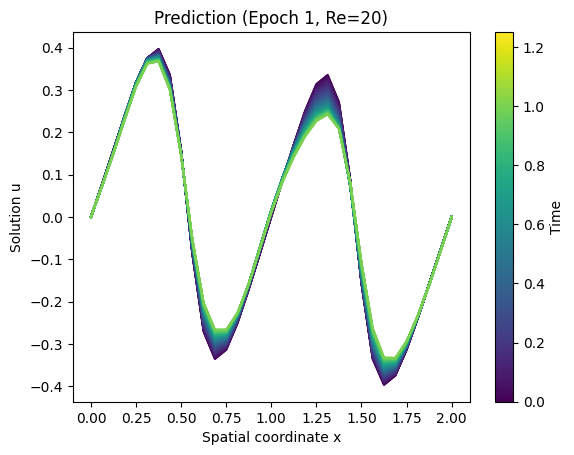

Epoch  10 | Total: 2.668e-01 | PINN: 3.800e-03 | Deriv: 1.622e-01 | IC-Deriv: 2.467e-01


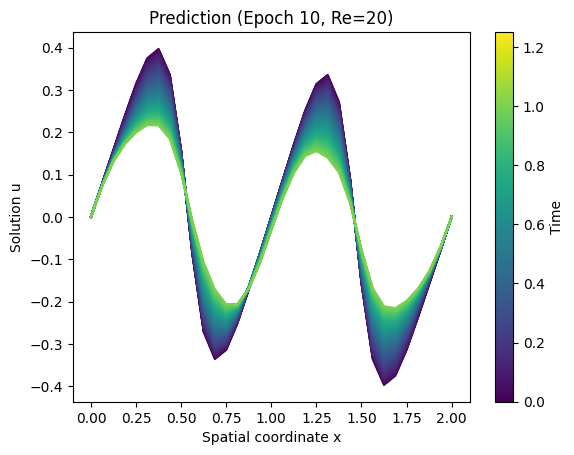

Epoch  20 | Total: 2.464e-01 | PINN: 4.341e-02 | Deriv: 5.496e-01 | IC-Deriv: 1.480e-01


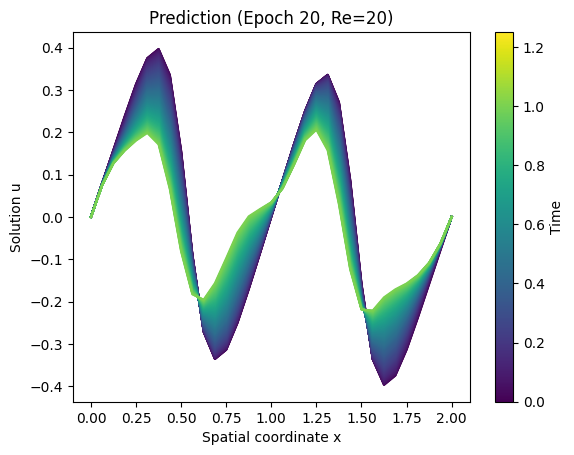

Epoch  30 | Total: 1.034e-01 | PINN: 5.415e-03 | Deriv: 8.164e-02 | IC-Deriv: 8.983e-02


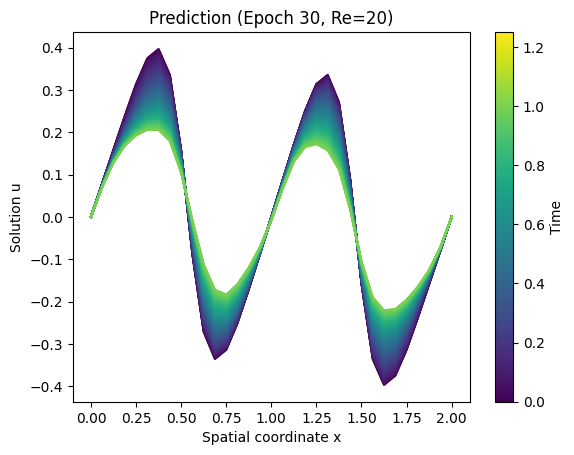

Epoch  40 | Total: 7.938e-02 | PINN: 5.222e-03 | Deriv: 5.426e-02 | IC-Deriv: 6.873e-02


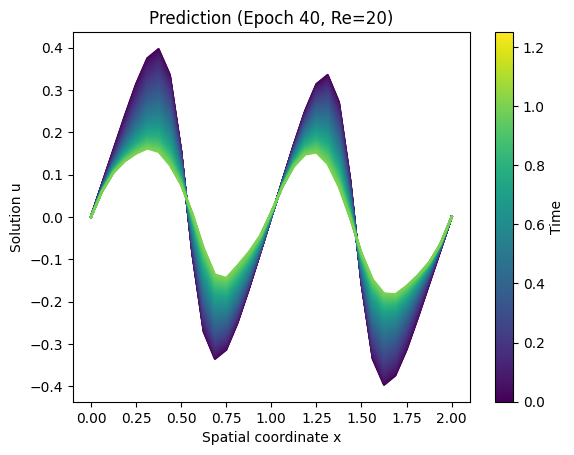

In [ ]:
plotter = SolutionPlotter(init_type=args.initType, coord_dim=args.coord_dim)

# Prepare a single batch for visualization
viz_batch = next(iter(dataloader_tr))

n_train_epochs = 100
history = {"loss": [], "pinn": [], "deriv": [], "ic_deriv": []}

for epoch in range(1, n_train_epochs + 1):
    epoch_loss, epoch_pinn, epoch_deriv, epoch_ic_deriv = 0.0, 0.0, 0.0, 0.0

    for i, batch in enumerate(dataloader_tr):
        for opt in optimizers.values():
            opt.zero_grad()

        results = model.compute_all_losses(batch, mode="train")

        results["loss_train"].backward()
        torch.nn.utils.clip_grad_norm_(model.decoder.parameters(), max_norm=1.0)
        torch.nn.utils.clip_grad_norm_(model.ode_func_net.parameters(), max_norm=1.0)
        if model.deriv_net is not None:
            torch.nn.utils.clip_grad_norm_(model.deriv_net.parameters(), max_norm=1.0)

        for opt in optimizers.values():
            opt.step()

        epoch_loss += results["loss_train"].item()
        epoch_pinn += results["loss_pinn"].item()
        epoch_deriv += results["loss_deriv"].item()
        epoch_ic_deriv += results["loss_ic_deriv"].item()

    n_batches = len(dataloader_tr)
    history["loss"].append(epoch_loss / n_batches)
    history["pinn"].append(epoch_pinn / n_batches)
    history["deriv"].append(epoch_deriv / n_batches)
    history["ic_deriv"].append(epoch_ic_deriv / n_batches)

    if epoch % 10 == 0 or epoch == 1:
        print(
            f"Epoch {epoch:3d} | Total: {epoch_loss/n_batches:.3e} | "
            f"PINN: {epoch_pinn/n_batches:.3e} | "
            f"Deriv: {epoch_deriv/n_batches:.3e} | "
            f"IC-Deriv: {epoch_ic_deriv/n_batches:.3e}"
        )

        # Prediction-only visualization
        with torch.no_grad():
            model_output = model.predict(viz_batch, mode="eval")

        # 1D shape: [B, T, H, 1, 1] -> [T, H]
        pred = model_output[0, :, :, 0, 0].detach().cpu().numpy()

        plotter.plot(
            u=[pred],
            title=[f"Prediction (Epoch {epoch}, Re={int(viz_batch['pars'][0])})"]
        )

In [ ]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.semilogy(history["loss"], "k-o", label="Total loss")
ax.semilogy(history["pinn"], "r--s", label="PINN loss")
ax.semilogy(history["deriv"], "b--^", label="Derivative loss")
ax.semilogy(history["ic_deriv"], "g--d", label="IC-derivative loss")
ax.set_xlabel("Epoch")
ax.set_ylabel("Loss")
ax.set_title("Training Progress")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

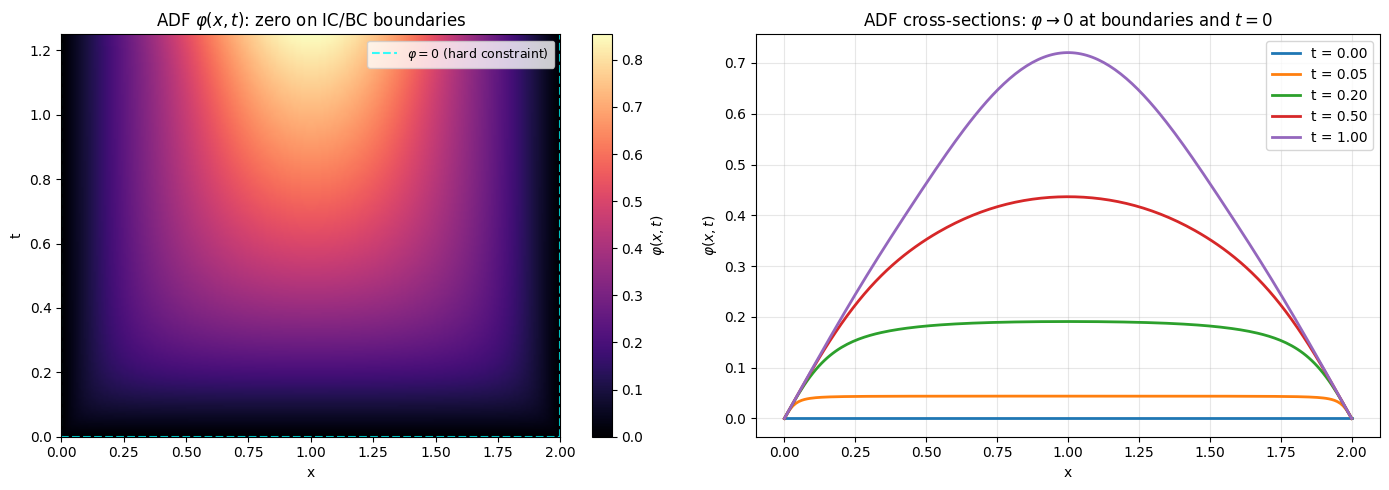

In [67]:
nx_v, nt_v = 200, 200
x_v = torch.linspace(args.x_boundaries[0], args.x_boundaries[1], nx_v)
t_v = torch.linspace(0, args.t_horizon, nt_v)
X, T = torch.meshgrid(x_v, t_v, indexing='ij')
xt_grid = torch.stack([X, T], dim=-1)

with torch.no_grad():
    phi_grid = model.decoder.ansatz.get_adf(xt_grid).cpu().numpy()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

im = axes[0].imshow(
    phi_grid.T,
    origin='lower',
    aspect='auto',
    extent=[args.x_boundaries[0], args.x_boundaries[1], 0, args.t_horizon],
    cmap='magma'
)
axes[0].set_xlabel('x')
axes[0].set_ylabel('t')
axes[0].set_title(r'ADF $\varphi(x,t)$: zero on IC/BC boundaries')
plt.colorbar(im, ax=axes[0], label=r'$\varphi(x,t)$')

for xb in args.x_boundaries:
    axes[0].axvline(x=xb, color='cyan', ls='--', lw=1.5, alpha=0.8)
axes[0].axhline(y=0, color='cyan', ls='--', lw=1.5, alpha=0.8, label=r'$\varphi=0$ (hard constraint)')
axes[0].legend(loc='upper right', fontsize=9)

t_slices = [0.0, 0.05, 0.2, 0.5, 1.0]
for ts in t_slices:
    idx = min(int(ts / args.t_horizon * (nt_v - 1)), nt_v - 1)
    axes[1].plot(x_v.numpy(), phi_grid[:, idx], lw=2, label=f't = {ts:.2f}')

axes[1].set_xlabel('x')
axes[1].set_ylabel(r'$\varphi(x, t)$')
axes[1].set_title(r'ADF cross-sections: $\varphi \to 0$ at boundaries and $t=0$')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

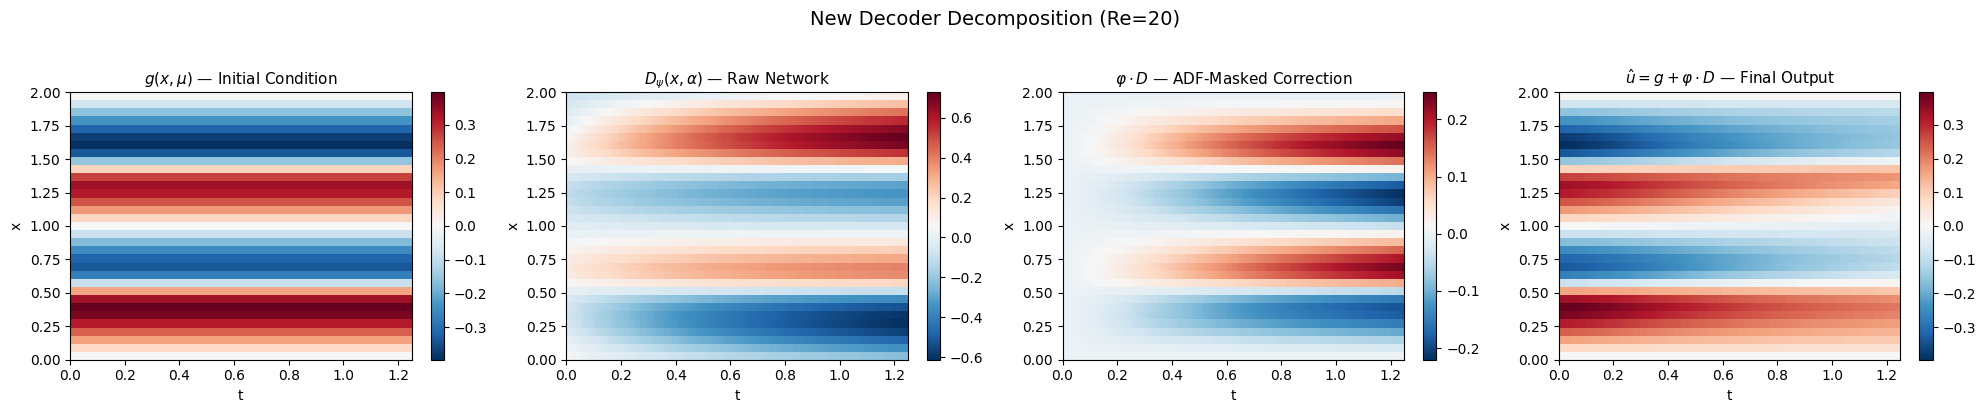

In [68]:
# Decoder decomposition: û = g(x,μ) + φ(x,t) · D_ψ(x, α)
# This shows how the ADF structure enforces hard constraints

batch = next(iter(dataloader_tr))
batch_vars = prepare_physics_inputs(args, batch, device)
xt = batch_vars["xt"]
pars_org = batch_vars["pars_org"]
Re_val = batch["pars"][0].item()

model.eval()
with torch.no_grad():
    _, codes = model.data_reconstruction(batch, eval_mode="code")
    g = model.decoder(xt, codes, params=pars_org, ret_type="init")
    D = model.decoder(xt, codes, params=pars_org, ret_type="deriv")
    phi = model.decoder.ansatz.get_adf(xt)
    u_hat = model.decoder(xt, codes, params=pars_org)
model.train()

# Reshape to (t, h) for plotting
g_np = g[0, :, :, 0, 0].cpu().numpy()
D_np = D[0, :, :, 0, 0].cpu().numpy()
phi_np = phi[0, :, :, 0, 0].cpu().numpy()
phiD_np = (phi * D)[0, :, :, 0, 0].cpu().numpy()
u_np = u_hat[0, :, :, 0, 0].cpu().numpy()

fig, axes = plt.subplots(1, 4, figsize=(20, 4))
extent = [0, args.t_horizon, args.x_boundaries[0], args.x_boundaries[1]]

titles = [
    r"$g(x, \mu)$ — Initial Condition",
    r"$D_\psi(x, \alpha)$ — Raw Network",
    r"$\varphi \cdot D$ — ADF-Masked Correction",
    r"$\hat{u} = g + \varphi \cdot D$ — Final Output",
]
data = [g_np, D_np, phiD_np, u_np]

for ax, d, title in zip(axes, data, titles):
    im = ax.imshow(d.T, origin="lower", aspect="auto", extent=extent, cmap="RdBu_r")
    ax.set_xlabel("t")
    ax.set_ylabel("x")
    ax.set_title(title, fontsize=11)
    plt.colorbar(im, ax=ax, fraction=0.046)

fig.suptitle(f"New Decoder Decomposition (Re={int(Re_val)})", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

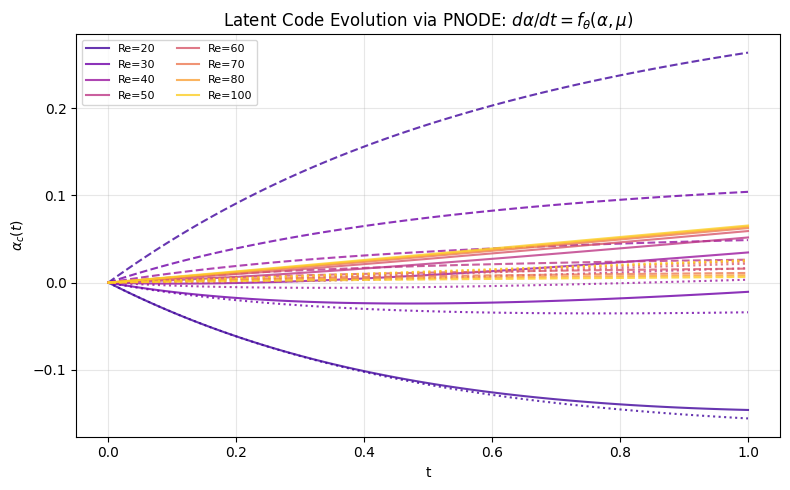

In [69]:
# Latent code α(t) evolution for different Re (PNODE dynamics)
fig, ax = plt.subplots(figsize=(8, 5))

model.eval()
re_colors = plt.cm.plasma(np.linspace(0.1, 0.9, len(dataset)))
linestyles = ['-', '--', ':']

with torch.no_grad():
    for i, batch in enumerate(dataloader_tr):
        _, codes = model.data_reconstruction(batch, eval_mode='code')
        alpha = codes[0, :, 0, 0, 0, :].cpu().numpy()  # (t_size, code_dim)
        t_vals = batch['t'][0].numpy()
        Re_val = batch['pars'][0].item()

        for c in range(min(3, alpha.shape[1])):
            ax.plot(t_vals, alpha[:, c], color=re_colors[i],
                    ls=linestyles[c], alpha=0.8,
                    label=f'Re={int(Re_val)}' if c == 0 else None)

model.train()

ax.set_xlabel('t')
ax.set_ylabel(r'$\alpha_c(t)$')
ax.set_title(r'Latent Code Evolution via PNODE: $d\alpha/dt = f_\theta(\alpha, \mu)$')
ax.legend(fontsize=8, ncol=2, loc='best')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

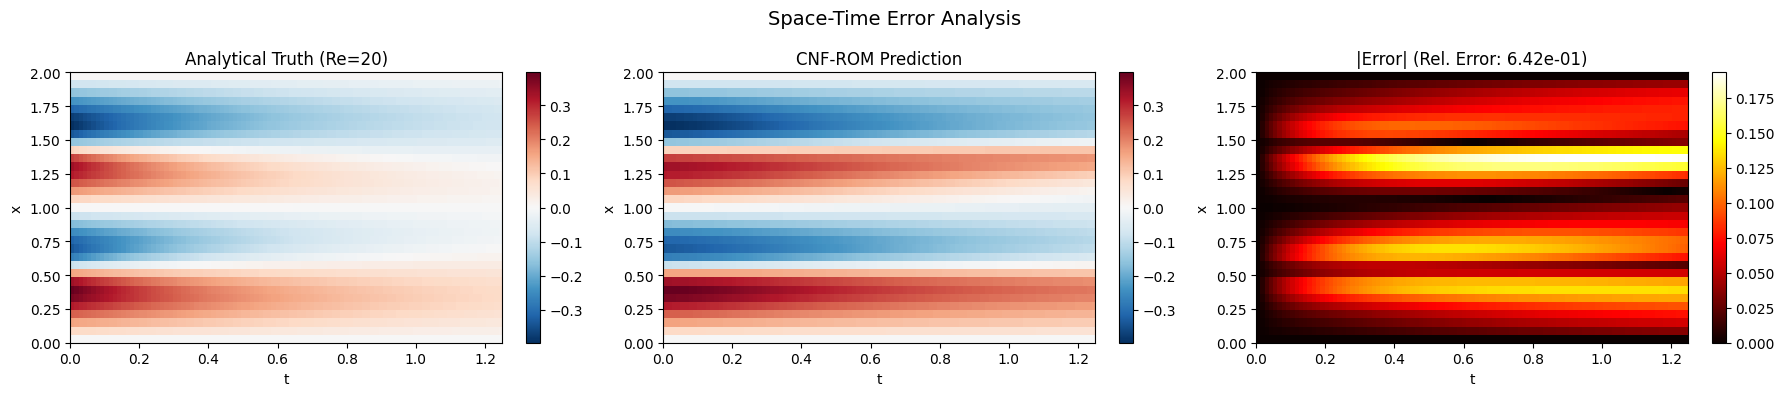

In [70]:
# Space-time error heatmap: analytical truth vs prediction vs pointwise error

batch = next(iter(dataloader_tr))
batch_vars = prepare_physics_inputs(args, batch, device)

xt = batch_vars["xt"]
pars_org = batch_vars["pars_org"]
t_size = batch_vars["t_size"]
h_size = batch_vars["h_size"]

Re = batch["pars"][0].item()

model.eval()
with torch.no_grad():
    pred = model.predict(batch, mode="predict")
model.train()

# Prediction: [B, T, H, 1, 1] -> [T, H]
pred_np = pred[0, :, :, 0, 0].detach().cpu().numpy()

# Analytical truth for 1D Burgers Cecchi / inan
if args.initType == "Cecchi":
    t_dec = xt[0, :, :, 0, 0, 1]
    gt = args.dataset_dict["train"].Cecchi(pars_org, xt[0, :, :, 0, 0, 0], t_dec)
    gt = gt.view(1, t_size, h_size, 1, 1)
elif args.initType == "inan":
    gt = args.dataset_dict["train"].inan(pars_org, xt[0, :, :, 0, 0, 0], xt[0, :, :, 0, 0, 1])
    gt = gt.view(1, t_size, h_size, 1, 1)
else:
    raise ValueError("No analytical ground truth available for this initType.")

gt_np = gt[0, :, :, 0, 0].detach().cpu().numpy()
error = np.abs(gt_np - pred_np)

fig, axes = plt.subplots(1, 3, figsize=(18, 4))
extent = [0, args.t_horizon, args.x_boundaries[0], args.x_boundaries[1]]

im0 = axes[0].imshow(gt_np.T, origin='lower', aspect='auto', extent=extent, cmap='RdBu_r')
axes[0].set_title(f'Analytical Truth (Re={int(Re)})')
plt.colorbar(im0, ax=axes[0], fraction=0.046)

im1 = axes[1].imshow(pred_np.T, origin='lower', aspect='auto', extent=extent, cmap='RdBu_r')
axes[1].set_title('CNF-ROM Prediction')
plt.colorbar(im1, ax=axes[1], fraction=0.046)

rel_err = np.linalg.norm(error) / np.linalg.norm(gt_np)
im2 = axes[2].imshow(error.T, origin='lower', aspect='auto', extent=extent, cmap='hot')
axes[2].set_title(f'|Error| (Rel. Error: {rel_err:.2e})')
plt.colorbar(im2, ax=axes[2], fraction=0.046)

for ax in axes:
    ax.set_xlabel('t')
    ax.set_ylabel('x')

plt.suptitle('Space-Time Error Analysis', fontsize=14)
plt.tight_layout()
plt.show()

In [24]:
# Cleanup
buffer_shelve.close()

NameError: name 'buffer_shelve' is not defined